## Part 1: Get the Free API 

### Setup and diagnostic check for the project environment

1. Sets the Workspace (os.chdir): It forces Python to change its "current working directory" to my specific thesis folder on my Mac. This is a crucial step because it ensures that whenever the rest of the code tries to open a file, it looks in the right place.

2. Confirms the Location (os.getcwd): It prints out the directory it just moved to, so we can visually verify that Python is indeed inside my tesi_francesca_peppoloni folder.

3. Performs a File Radar Check (os.path.exists): It acts as a scanner to verify if the three most important files for my experiment are actually inside that folder. It will print True if they are there, or False if they are missing:

        api.env: my API keys for Llama-3.

        geography-db.added-in-2020.sqlite: the actual database to execute the queries.

        geography.json: The dataset containing the questions.

In [1]:
import os

# Set working directory to the project folder
# This ensures api.env, the SQLite database, and CSV files are found correctly
os.chdir("/Users/francescapeppoloni/Desktop/tesi/tesi_francesca_peppoloni")

print("Working directory:", os.getcwd())
print("api.env found:", os.path.exists("api.env"))
print("Database found:", os.path.exists("geography-db.added-in-2020.sqlite"))
print("geography.json found:", os.path.exists("geography.json"))

Working directory: /Users/francescapeppoloni/Desktop/tesi/tesi_francesca_peppoloni
api.env found: True
Database found: True
geography.json found: True


### Package installation command

It downloads and sets up the Groq library so that my Python code has the necessary tools to communicate with Groq's AI models.

In [2]:
!pip install groq

## Part 2: The Setup (Libraries and Connections)

We need to tell Python which external tools to use and open the connections to the database and the LLM. If this part runs without errors, it means the API key is correct and Python successfully found .sqlite file.

In [33]:
import json # To read geography.json file
import time # To run the stopwatches for timing metrics
import sqlite3 # To talk to the geography SQLite database
import os
import numpy as np
import pandas as pd
from groq import Groq # To talk to Llama 3 
from dotenv import load_dotenv

load_dotenv("api.env") # it read the .env file
API_KEY = os.getenv("GROQ_API_KEY")
if not API_KEY:
    raise ValueError("API key not found. Check api.env")

client = Groq(api_key=API_KEY)

conn = sqlite3.connect("geography-db.added-in-2020.sqlite")
cursor = conn.cursor() # The 'cursor' is what actually executes the SQL commands
print("Setup done")

Setup done


## Part 3: Loading the Data and the Schema

Now we load the actual questions we want to test and define the "map" of the database so the AI knows what tables exist.

In [34]:
# 1. Open the JSON file and load the dataset
with open("geography.json", "r") as f:
    dataset = json.load(f)

# 2. Correct schema: tables, lowercase
geography_schema = """
Database Tables and Columns (all values stored in lowercase):
- state (state_name, population, area, country_name, capital, density)
- border_info (state_name, border)
- city (city_name, state_name, population, country_name)
- highlow (state_name, highest_point, highest_elevation, lowest_point, lowest_elevation)
- river (river_name, length, traverse, country_name)
- mountain (mountain_name, mountain_altitude, state_name, country_name)
- lake (lake_name, area, state_name, country_name)

IMPORTANT: All text values in the database are lowercase.
Examples: state_name='texas', city_name='houston', country_name='usa'
"""

def resolve_question(item):
    """
    Replace masked entity placeholders (e.g. state_name0) in the
    natural-language question with their actual example values.
    Returns the resolved question string ready to be sent to the LLM.
    """
    sentence = item['sentences'][0]
    text = sentence['text']
    variables = sentence.get('variables', {})
    for var_name, var_value in variables.items():
        text = text.replace(var_name, var_value)
    return text

def resolve_gold_sql(item):
    """
    Replace masked entity placeholders in the gold SQL query with
    their actual example values, mirroring the substitution applied
    to the natural-language question. Returns the resolved SQL string.
    """
    sql = item['sql'][0]
    variables = item.get('variables', [])
    for var in variables:
        sql = sql.replace(f'"{var["name"]}"', f'"{var["example"]}"')
    return sql

# Check fix
item0 = dataset[0]
print("Raw text:   ", dataset[0]['sentences'][0]['text'])
print("Fixed text: ", resolve_question(dataset[0]))
print("Raw gold:   ", dataset[0]['sql'][0])
print("Fixed gold: ", resolve_gold_sql(dataset[0]))

Raw text:    what is the biggest city in state_name0
Fixed text:  what is the biggest city in arizona
Raw gold:    SELECT CITYalias0.CITY_NAME FROM CITY AS CITYalias0 WHERE CITYalias0.POPULATION = ( SELECT MAX( CITYalias1.POPULATION ) FROM CITY AS CITYalias1 WHERE CITYalias1.STATE_NAME = "state_name0" ) AND CITYalias0.STATE_NAME = "state_name0" ;
Fixed gold:  SELECT CITYalias0.CITY_NAME FROM CITY AS CITYalias0 WHERE CITYalias0.POPULATION = ( SELECT MAX( CITYalias1.POPULATION ) FROM CITY AS CITYalias1 WHERE CITYalias1.STATE_NAME = "arizona" ) AND CITYalias0.STATE_NAME = "arizona" ;


**Dynamic De-Masking in Text-to-SQL Evaluation**

1. The Problem: Entity Masking and the "Empty Set" Paradox
In academic Text-to-SQL datasets like GeoQuery, researchers often employ a technique called Entity Masking (or Variable Abstraction). Specific entities, such as real state or city names, are replaced with generic placeholders (e.g., state_name0, city_name0). The primary goal of this technique is to prevent Large Language Models (LLMs) from bypassing the reasoning process by relying on their pre-trained geographical knowledge, thereby forcing them to demonstrate pure SQL generation capabilities.

    However, this creates a structural mismatch during the execution-based evaluation. While the generated queries rely on these masked placeholders, the underlying SQLite database is populated with real-world data (e.g., "Texas", "Arizona"). As a result, executing a structurally perfect SQL query that contains a placeholder (e.g., WHERE state_name = 'state_name0') against the real database invariably returns an empty set ([]). This artificially degrades the Execution Accuracy metric, as the evaluation script cannot natively distinguish between flawed SQL logic and a simple entity mismatch.

2. The Solution: Dynamic De-Masking (Value Replacement)
To overcome this limitation without altering the integrity of the original database, a Dynamic De-Masking pipeline was engineered prior to query execution.

    The original JSON dataset inherently provides a hidden dictionary of real values corresponding to each placeholder for every specific test case. By implementing custom Python functions (such as resolve_question and resolve_gold_sql), the evaluation script intercepts both the natural language prompt and the human-annotated Gold Standard query. It programmatically iterates through the dictionary and maps the placeholders back to their real-world equivalents (e.g., automatically substituting state_name0 with arizona).

3. The Impact on Evaluation Metrics
This dynamic substitution is applied before feeding the prompt to the LLM. Once the LLM generates its SQL query based on the "de-masked" natural language prompt, both the LLM's query and the Gold Standard query are executed against the database using real, queryable entities.

    This architectural fix ensures that the Execution Accuracy metric rigorously evaluates the structural correctness and semantic equivalence of the generated SQL logic (e.g., correctly applying ORDER BY ... LIMIT 1 versus MAX()), completely eliminating the false negatives caused by artificial empty sets.

In [6]:
import sqlite3
import pandas as pd
from IPython.display import display, HTML

# 1. Connect to the Database
db_path = "geography-db.added-in-2020.sqlite" 
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print(" DATABASE SCHEMA & COMPLEXITY ANALYSIS")

# 2. Get all table names (ignoring internal SQLite tables)
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%';")
tables = [t[0] for t in cursor.fetchall()]

print(f"Total Tables Found: {len(tables)}\n")

# 3. Loop through and analyze every table automatically
for table in tables:
    # Get row count
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    row_count = cursor.fetchone()[0]
    
    print(f" TABLE: {table.upper()} | Rows: {row_count}")
    
    # Get Column Data (Schema)
    schema_df = pd.read_sql_query(f"PRAGMA table_info({table});", conn)
    # Rename for cleaner printing
    schema_df = schema_df[['name', 'type', 'notnull', 'pk']].rename(
        columns={'name': 'Column Name', 'type': 'Data Type', 'notnull': 'Required', 'pk': 'Primary Key'}
    )
    
    # Get a 2-row sample of what the data actually looks like
    sample_df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 2;", conn)
    
    # Display nicely in Jupyter
    display(HTML("<b>Schema:</b>"))
    display(schema_df)
    display(HTML("<b>Sample Data:</b>"))
    display(sample_df)
    print("-" * 60 + "\n")

 DATABASE SCHEMA & COMPLEXITY ANALYSIS
Total Tables Found: 7

 TABLE: BORDER_INFO | Rows: 218


,Column Name,Data Type,Required,Primary Key
0,state_name,TEXT,0,0
1,border,TEXT,0,0


,state_name,border
0,alabama,tennessee
1,alabama,georgia


------------------------------------------------------------

 TABLE: CITY | Rows: 386


,Column Name,Data Type,Required,Primary Key
0,city_name,TEXT,0,0
1,population,INT,0,0
2,country_name,varchar(3),1,0
3,state_name,TEXT,0,0


...

,river_name,length,country_name,traverse
0,mississippi,3778,usa,minnesota
1,mississippi,3778,usa,wisconsin


------------------------------------------------------------

 TABLE: STATE | Rows: 51


,Column Name,Data Type,Required,Primary Key
0,state_name,TEXT,0,0
1,population,INT,0,0
2,area,double,0,0
3,country_name,varchar(3),1,0
4,capital,TEXT,0,0
5,density,double,0,0


,state_name,population,area,country_name,capital,density
0,alabama,3894000,51700.0,usa,montgomery,75.319149
1,alaska,401800,591000.0,usa,juneau,0.679865


------------------------------------------------------------



## Part 4: The Brain (Talking to the LLM)

Now we loop through the dataset, build a prompt, start a timer and ask the AI for the SQL. We can run this whenever we want to inspect exactly what the AI is generating for a single prompt without waiting for a whole batch to finish.

In [35]:
# Testing only the very first question (with variable resolution)
item = dataset[0]
question    = resolve_question(item)
truth_query = resolve_gold_sql(item)

# 1. Build the prompt (same as zero-shot full run)
prompt = (
    f"You are an expert SQL developer. "
    f"Use ONLY this schema:\n{geography_schema}\n\n"
    f"RULES:\n"
    f"1. Use ONLY lowercase table and column names\n"
    f"2. All string values in WHERE clauses must be lowercase\n"
    f"3. Return ONLY the SQL query, no explanation, no markdown\n\n"
    f"Question: {question}\n"
    f"SQL:"
)

# 2. Start the Generation Timer
start_time = time.time()

# 3. Ask Groq
chat_completion = client.chat.completions.create(
    messages=[{"role": "user", "content": prompt}],
    model="llama-3.3-70b-versatile",
    temperature=0.0
)
llm_query = (chat_completion.choices[0].message.content
             .strip()
             .replace("```sql", "")
             .replace("```", "")
             .strip())

# 4. Stop the timer
generation_time = time.time() - start_time

# 5. Evaluate results
string_match = llm_query.lower() == truth_query.lower()

try:
    cursor.execute(truth_query)
    truth_result = cursor.fetchall()
except Exception as e:
    truth_result = []
    print(f"Gold SQL error: {e}")

try:
    cursor.execute(llm_query)
    llm_result = cursor.fetchall()
    execution_match = set(llm_result) == set(truth_result)
except Exception as e:
    llm_result = f"SQL Error: {e}"
    execution_match = False

print(f"Question:         {question}")
print(f"Truth Query:      {truth_query}")
print(f"LLM Query:        {llm_query}")
print(f"String Match:     {string_match}")
print(f"Execution Match:  {execution_match}")
print(f"Time taken:       {generation_time:.2f} seconds")

Question:         what is the biggest city in arizona
Truth Query:      SELECT CITYalias0.CITY_NAME FROM CITY AS CITYalias0 WHERE CITYalias0.POPULATION = ( SELECT MAX( CITYalias1.POPULATION ) FROM CITY AS CITYalias1 WHERE CITYalias1.STATE_NAME = "arizona" ) AND CITYalias0.STATE_NAME = "arizona" ;
LLM Query:        select city_name from city where state_name = 'arizona' order by population desc limit 1
String Match:     False
Execution Match:  True
Time taken:       0.93 seconds


## Part 5: Exact String Match and Execution Accuracy

Now we have two queries: the truth_query (from the JSON) and the llm_query (from the AI). We need to score them.

In [36]:
# Metric 1: Exact String Match, set() ignores row order
if set(truth_result) == set(llm_result):
        execution_score = 1

# Metric 2: Execution Accuracy
truth_result    = None
llm_result      = None
execution_score = 0
db_execution_time = 0.0

# Run the gold query
try:
    cursor.execute(truth_query)
    truth_result = cursor.fetchall()
except Exception as e:
    truth_result = f"Error in Truth SQL: {e}"

# Run the LLM query
try:
    exec_start = time.perf_counter()
    cursor.execute(llm_query)
    llm_result = cursor.fetchall()
    db_execution_time = time.perf_counter() - exec_start

    # set() ignores row order — same logic as the full run
    if isinstance(truth_result, list) and set(llm_result) == set(truth_result):
        execution_score = 1

except Exception as e:
    llm_result = f"SQL_ERROR: {e}"
    execution_score = 0

print("SINGLE TEST RESULTS")
print(f"String Match:    {string_match}")
print(f"Truth Result:    {truth_result}")
print(f"LLM Result:      {llm_result}")
print(f"Execution Score: {execution_score}")
print(f"DB Exec Time:    {db_execution_time:.4f}s")

SINGLE TEST RESULTS
String Match:    False
Truth Result:    [('phoenix',)]
LLM Result:      [('phoenix',)]
Execution Score: 1
DB Exec Time:    0.0001s


**Defining the Evaluation Metrics**

The first step involved clarifying the two required methods for evaluating the AI's performance:
- **Exact String Match**: A strict comparison to check if the generated SQL text is identical to the "Truth" SQL text.
- **Execution Accuracy**: A practical evaluation where both the generated query and the "Truth" query are executed on a live database, and their final outputs are compared. This determines if the underlying logic is correct, even if the phrasing differs.

## Part 6: Test on 5 questions

This is the loop. It runs through multiple questions (e.g., dataset[:5] or dataset[:100]), tallies up the scores, and prints the final statistics needed for the thesis.

In [37]:
total_tested = 5
total_string_match = 0
total_execution_match = 0

print(f"STARTING ZERO-SHOT PROBE ({total_tested} Questions)\n")

for i, item in enumerate(dataset[:total_tested]):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    prompt = (
        f"You are an expert SQL developer. "
        f"Use ONLY this schema:\n{geography_schema}\n\n"
        f"RULES:\n"
        f"1. Use ONLY lowercase table and column names\n"
        f"2. All string values in WHERE clauses must be lowercase\n"
        f"3. Return ONLY the SQL query, no explanation, no markdown\n\n"
        f"Question: {question}\n"
        f"SQL:"
    )

    try:
        chat_completion = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile",
            temperature=0.0
        )
        llm_query = (chat_completion.choices[0].message.content
                     .strip().replace("```sql", "").replace("```", "").strip())
    except Exception as e:
        llm_query = f"API_ERROR: {e}"

    # String Match
    if llm_query.lower() == truth_query.lower():
        total_string_match += 1

    # Execution Accuracy with set()
    try:
        cursor.execute(truth_query)
        truth_result = cursor.fetchall()
    except Exception:
        truth_result = []

    try:
        cursor.execute(llm_query)
        llm_result = cursor.fetchall()
        if set(llm_result) == set(truth_result):
            total_execution_match += 1
    except Exception:
        pass

    print(f"  Q{i+1}: {question[:70]}...")

print(f"\n{'='*40}")
print(f"PROBE RESULTS")
print(f"String Match:       {total_string_match}/{total_tested}")
print(f"Execution Accuracy: {total_execution_match}/{total_tested}")

STARTING ZERO-SHOT PROBE (5 Questions)

  Q1: what is the biggest city in arizona...
  Q2: which rivers run through the state with the largest city in the us...
  Q3: how big is texas...
  Q4: how many people live in washington...
  Q5: what state has the smallest population...

PROBE RESULTS
String Match:       0/5
Execution Accuracy: 4/5


## Part 7: Data Collection Pipeline

1. **Setting Up the Storage**

Before asking the AI any questions, the code creates an empty list (results_data = []). This acts as an empty folder where the results of every single test will be stored.

2. **Running the Experiment (The Loop)**

The script takes the first 5 questions from the dataset and runs them through the testing process one by one:

- **Generation**: It sends the database schema and the question to the Llama 3.1 model and records how long the AI takes to think.

- **Evaluation**: It calculates the String Match score (comparing the text) and the Execution Accuracy score (running the queries on the database and comparing the output).

3. **Logging the Details**

Instead of just printing the final score to the screen and forgetting it, the code packages all the important details—the original question, the Truth SQL, the AI's generated SQL, the timers, and both scores—into a structured record (a dictionary) and drops it into that results_data list.

4. **Building and Saving the Spreadsheet**

Once all 5 questions are finished, the Pandas library (pd.DataFrame) takes that list of records and transforms it into a clean, two-dimensional table with rows and columns. Finally, it exports that table to the computer's hard drive as a .csv file (llama3_evaluation_results.csv), making the data permanent and ready to be opened in Excel or used for thesis charts.

In [38]:
import pandas as pd

# Demo: how the data collection loop works (5 questions, with variable resolution)
results_data = []
total_tested  = 5
total_string_match    = 0
total_execution_match = 0

print(f"STARTING DATA COLLECTION DEMO ({total_tested} Questions)\n")

for i, item in enumerate(dataset[:total_tested]):
    question    = resolve_question(item)   # resolves placeholders like state_name0
    truth_query = resolve_gold_sql(item)   # resolves variables in the gold SQL

    prompt = (
        f"You are an expert SQL developer. "
        f"Use ONLY this schema:\n{geography_schema}\n\n"
        f"RULES:\n"
        f"1. Use ONLY lowercase table and column names\n"
        f"2. Return ONLY the SQL query, no explanation, no markdown\n\n"
        f"Question: {question}\n"
        f"SQL:"
    )

    try:
        chat_completion = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile",
            temperature=0.0
        )
        llm_query = (chat_completion.choices[0].message.content
                     .strip().replace("```sql", "").replace("```", "").strip())
    except Exception as e:
        llm_query = f"API_ERROR: {e}"

    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0
    if string_match_score:
        total_string_match += 1

    try:
        cursor.execute(truth_query)
        truth_result = cursor.fetchall()
    except Exception:
        truth_result = []

    try:
        cursor.execute(llm_query)
        llm_result = cursor.fetchall()
        if set(llm_result) == set(truth_result):
            total_execution_match += 1
    except Exception:
        pass

    results_data.append({
        "Question ID":   i + 1,
        "Question Text": question,
        "Truth Query":   truth_query,
        "LLM Query":     llm_query,
        "String Match":  string_match_score
    })
    print(f"  Q{i+1}: {question[:60]}...")

demo_df = pd.DataFrame(results_data)
print(f"\n{'='*40}")
print(f"DEMO RESULTS")
print(f"String Match:       {total_string_match}/{total_tested}")
print(f"Execution Accuracy: {total_execution_match}/{total_tested}")
demo_df.head()

STARTING DATA COLLECTION DEMO (5 Questions)

  Q1: what is the biggest city in arizona...
  Q2: which rivers run through the state with the largest city in ...
  Q3: how big is texas...
  Q4: how many people live in washington...
  Q5: what state has the smallest population...

DEMO RESULTS
String Match:       0/5
Execution Accuracy: 4/5


,Question ID,Question Text,Truth Query,LLM Query,String Match
0,1,what is the biggest city in arizona,SELECT CITYalias0.CITY_NAME FROM CITY AS CITYa...,select city_name from city where state_name = ...,0
1,2,which rivers run through the state with the la...,SELECT RIVERalias0.RIVER_NAME FROM RIVER AS RI...,select r.river_name from river r where r.count...,0
2,3,how big is texas,SELECT STATEalias0.AREA FROM STATE AS STATEali...,"select area, population from state where state...",0
3,4,how many people live in washington,SELECT STATEalias0.POPULATION FROM STATE AS ST...,select population from state where state_name ...,0
4,5,what state has the smallest population,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,select state_name from state order by populati...,0


## Part 8: Full Run (Zero-Shot Prompting)

What to change for the **Full Run**:

- **Iterate over all questions**: change `dataset[:5]` to `dataset` to run all 246 questions.
- **Use resolve_question() and resolve_gold_sql()**: ensures placeholders like `state_name0` are replaced with real values before sending to the LLM.
- **Use set() for execution comparison**: `set(llm_result) == set(truth_result)` compares results ignoring row order, which is more robust.
- **Output file**: results are saved to `results/llama3_zeroshot_FULL_results.csv`.


In [ ]:
import time
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

results_data = []
total_tested = len(dataset)
total_string_match = 0
total_execution_match = 0

print(f"STARTING ZERO-SHOT FULL EVALUATION ({total_tested} Questions)\n")
print("This will take a few minutes...\n")

for i, item in enumerate(dataset):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    prompt = (
        f"You are an expert SQL developer. "
        f"Use ONLY this schema:\n{geography_schema}\n\n"
        f"RULES:\n"
        f"1. Use ONLY lowercase table and column names\n"
        f"2. All string values in WHERE clauses must be lowercase\n"
        f"3. Return ONLY the SQL query, no explanation, no markdown\n\n"
        f"Question: {question}\n"
        f"SQL:"
    )

    success  = False
    retries  = 0
    llm_query = "API_ERROR"
    start_time = time.time()

    while not success and retries < 3:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0
            )
            llm_query = (chat_completion.choices[0].message.content
                         .strip()
                         .replace("```sql", "")
                         .replace("```", "")
                         .strip())
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate limit hit. Waiting 60s... (attempt {retries+1}/3)")
                time.sleep(60)
                retries += 1
            else:
                llm_query = f"API_ERROR: {e}"
                success = True

    generation_time = time.time() - start_time

    # String match
    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0
    if string_match_score:
        total_string_match += 1

    # Execution accuracy with set()
    truth_result    = []
    llm_exec_time   = 0.0
    truth_exec_time = 0.0
    execution_score = 0
    error_msg       = ""  

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:        
        error_msg = f"Gold SQL Error: {e}"


    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0
        if set(llm_result) == set(truth_result):
            execution_score = 1
            total_execution_match += 1
        else:
            error_msg = "Data Mismatch"   
    except Exception as e:               
        error_msg = f"SQL Error: {e}"    


    results_data.append({
        "Question ID":          i + 1,
        "Question Text":        question,
        "Truth Query":          truth_query,
        "LLM Query":            llm_query,
        "Generation Time (s)":  round(generation_time, 3),
        "Truth Exec Time (s)":  round(truth_exec_time, 4),
        "LLM Exec Time (s)":    round(llm_exec_time, 4),
        "String Match":         string_match_score,
        "Execution Score":      execution_score,
        "Error_Message":        error_msg  
    })

    # Save checkpoint every 25 questions
    if (i + 1) % 25 == 0:
        pd.DataFrame(results_data).to_csv("results/llama3_zeroshot_FULL_results.csv", index=False)

    if (i + 1) % 10 == 0 or (i + 1) == total_tested:
        current_acc = total_execution_match / (i + 1) * 100
        print(f"  Processed {i+1}/{total_tested} | Accuracy so far: {current_acc:.1f}%")

# Final save
df_zs = pd.DataFrame(results_data)
df_zs.to_csv("results/llama3_zeroshot_FULL_results.csv", index=False)

print(f"\n{'='*50}")
print(f"ZERO-SHOT COMPLETE")
print(f"String Match:       {total_string_match}/{total_tested}")
print(f"Execution Accuracy: {total_execution_match}/{total_tested} = "
      f"{total_execution_match/total_tested*100:.1f}%")
print(f"Saved to: results/llama3_zeroshot_FULL_results.csv")

We regenerate only the **Error Message** without having to run the full run of Zero-Shot again, by using the llama3_zeroshot_FULL_results.csv

In [116]:
import pandas as pd
import sqlite3

# Reload existing CSV
df = pd.read_csv("results/llama3_zeroshot_FULL_results.csv")

if 'Error_Message' not in df.columns:
    print("Adding Error_Message column without re-running API calls...")
    error_msgs = []
    for _, row in df.iterrows():
        if row['Execution Score'] == 1:
            error_msgs.append("")
            continue
        # Re-execute both queries to determine error type
        try:
            cursor.execute(str(row['Truth Query']))
            truth_result = cursor.fetchall()
            try:
                cursor.execute(str(row['LLM Query']))
                llm_result = cursor.fetchall()
                error_msgs.append("Data Mismatch")
            except Exception as e:
                error_msgs.append(f"SQL Error: {e}")
        except Exception as e:
            error_msgs.append(f"Gold SQL Error: {e}")
    
    df['Error_Message'] = error_msgs
    df.to_csv("results/llama3_zeroshot_FULL_results.csv", index=False)
    print(f"  ✓ Added Error_Message to {len(df)} rows")
else:
    print("Error_Message already exists — nothing to do.")

Adding Error_Message column without re-running API calls...
  ✓ Added Error_Message to 246 rows


### Results: Zero-Shot Baseline

The zero-shot evaluation yielded an **Execution Accuracy of 60.6%** (149/246 queries correct),
establishing the baseline for this experiment. The String Match score of 0% confirms that the
model never reproduces the gold query verbatim — this is expected, as multiple syntactically
different SQL queries can return identical results. Execution Accuracy is therefore the
meaningful metric throughout this study.

Average generation time was **3.1 seconds** per query, compared to **0.003 seconds**
for database execution — roughly 1,000× slower — illustrating the latency cost of
natural language understanding.

## Part 9: Data Analysis

Why the AI got 97 questions wrong? Did it hallucinate columns? Did it mess up JOIN statements? Did it use MAX() when it should have used MIN()? Let's find out.

In [7]:
import pandas as pd

# 1. Load zero-shot results
df = pd.read_csv("results/llama3_zeroshot_FULL_results.csv")

# 2. Filter the table to show ONLY the questions the AI got wrong
failed_queries = df[df['Execution Score'] == 0]

print(f"Total Failed Queries to analyze: {len(failed_queries)}")
print("Here are the first 10 mistakes the AI made:\n")

# 3. Display the Question, the Truth and the AI's mistake
failed_queries[['Question ID', 'Question Text', 'Truth Query', 'LLM Query']].head(10)

Total Failed Queries to analyze: 97
Here are the first 10 mistakes the AI made:



,Question ID,Question Text,Truth Query,LLM Query
1,2,which rivers run through the state with the la...,SELECT RIVERalias0.RIVER_NAME FROM RIVER AS RI...,select r.river_name from river r join city c o...
2,3,how big is texas,SELECT STATEalias0.AREA FROM STATE AS STATEali...,"select area, population from state where state..."
8,9,name the major lakes in michigan,SELECT LAKEalias0.LAKE_NAME FROM LAKE AS LAKEa...,select lake_name from lake where state_name = ...
13,14,what is the highest point in each state whose ...,"SELECT HIGHLOWalias0.HIGHEST_POINT , HIGHLOWal...","select t1.state_name, t1.highest_point \nfrom ..."
18,19,name all the rivers in colorado,SELECT RIVERalias0.RIVER_NAME FROM RIVER AS RI...,select river_name from river where traverse = ...
24,25,which states lie on the largest river in the u...,SELECT RIVERalias0.TRAVERSE FROM RIVER AS RIVE...,select distinct t1.state_name from state t1 in...
28,29,give me the longest river that passes through ...,SELECT RIVERalias0.RIVER_NAME FROM RIVER AS RI...,"select river_name, length from river where cou..."
33,34,what is the highest point in states bordering ...,SELECT HIGHLOWalias0.HIGHEST_POINT FROM HIGHLO...,"select t1.highest_point, t1.highest_elevation ..."
35,36,what is the longest river that passes the stat...,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,"select river_name, length from river where tra..."
38,39,which state borders most states,SELECT DERIVED_TABLEalias1.STATE_NAME FROM ( S...,select state_name from border_info group by st...


## Part 10: Data Visualization

## Pie Chart

Chart saved as 'accuracy_pie_chart.png'!


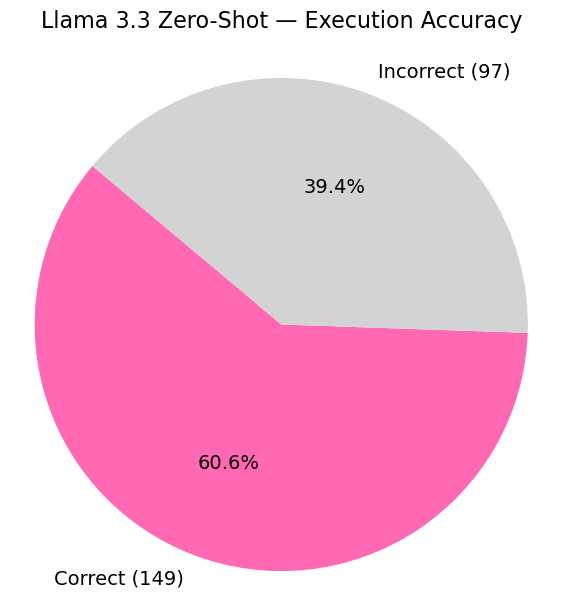

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load zero-shot results
df = pd.read_csv("results/llama3_zeroshot_FULL_results.csv")

# 2. Count Correct (1) and Incorrect (0) queries
score_counts = df['Execution Score'].value_counts()
correct_count   = score_counts.get(1, 0)
incorrect_count = score_counts.get(0, 0)

# 3. Set up labels and colors
labels = [f'Correct ({correct_count})', f'Incorrect ({incorrect_count})']
sizes  = [correct_count, incorrect_count]
colors = ['hotpink', '#d3d3d3']

# 4. Create the Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 14})
plt.title('Llama 3.3 Zero-Shot — Execution Accuracy', fontsize=16, pad=20)
plt.axis('equal')

plt.savefig('accuracy_pie_chart.png', bbox_inches='tight', dpi=300)
print("Chart saved as 'accuracy_pie_chart.png'!")
plt.show()

## Bar Chart

Bar chart saved as 'accuracy_bar_chart.png'!


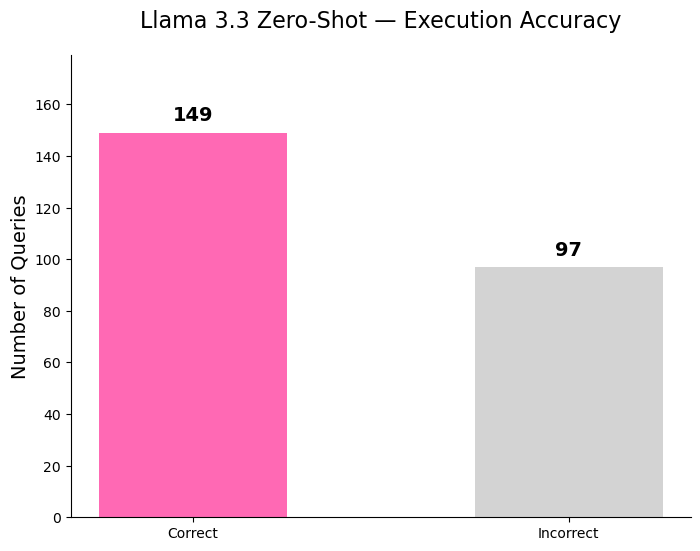

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load zero-shot results
df = pd.read_csv("results/llama3_zeroshot_FULL_results.csv")

# 2. Count Correct and Incorrect
score_counts = df['Execution Score'].value_counts()
correct_count   = score_counts.get(1, 0)
incorrect_count = score_counts.get(0, 0)

categories = ['Correct', 'Incorrect']
counts = [correct_count, incorrect_count]
colors = ['hotpink', '#d3d3d3']

# 3. Create the Bar Chart
plt.figure(figsize=(8, 6))
bars = plt.bar(categories, counts, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 3,
             str(int(height)), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.title('Llama 3.3 Zero-Shot — Execution Accuracy', fontsize=16, pad=20)
plt.ylabel('Number of Queries', fontsize=14)
plt.ylim(0, max(counts) + 30)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('accuracy_bar_chart.png', bbox_inches='tight', dpi=300)
print("Bar chart saved as 'accuracy_bar_chart.png'!")
plt.show()

## Part 11: The Speed vs. Efficiency Analysis

A prominent discussion in contemporary computer science concerns the computational overhead—often referred to as the "cost"—of artificial intelligence. While Large Language Models (LLMs) provide significant accessibility benefits by translating natural language into SQL queries for non-technical users, this translation process introduces substantial latency. 

To quantify this overhead, this analysis compares the duration required for the Llama 3.1 model to generate a query (Generation Time) against the time required for the SQLite engine to execute the query and retrieve the data (Database Execution Time). In practice, the generative AI process often requires orders of magnitude more time than deterministic database execution.

SPEED & EFFICIENCY REPORT (Zero-Shot)
Average AI Generation Time: 3.1080 seconds
Average DB Execution Time:  0.00313 seconds
The AI took ~992x longer to write the query than the DB took to run it!

Speed chart saved as 'speed_comparison_chart.png'!


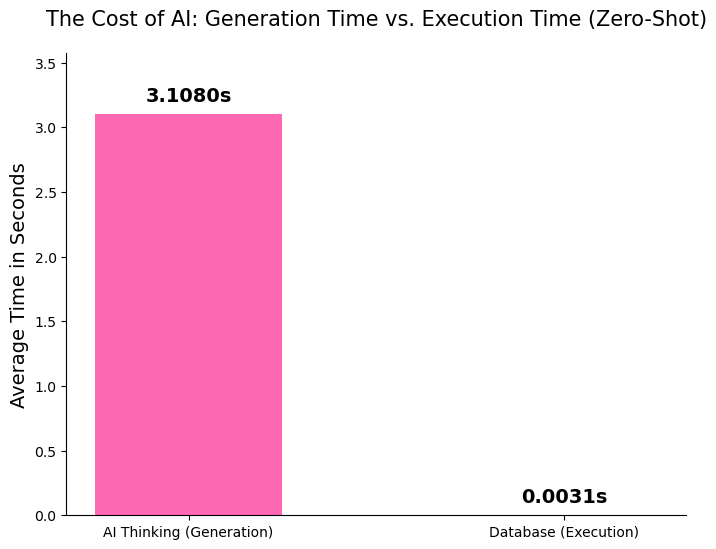

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load zero-shot results
df = pd.read_csv("results/llama3_zeroshot_FULL_results.csv")

# 2. Calculate the average times
# New zero-shot CSV has 'Generation Time (s)' and 'LLM Exec Time (s)'
avg_gen_time = df['Generation Time (s)'].mean()
avg_db_time  = df['LLM Exec Time (s)'].mean()

print("SPEED & EFFICIENCY REPORT (Zero-Shot)")
print(f"Average AI Generation Time: {avg_gen_time:.4f} seconds")
print(f"Average DB Execution Time:  {avg_db_time:.5f} seconds")
if avg_db_time > 0:
    ratio = avg_gen_time / avg_db_time
    print(f"The AI took ~{int(ratio):,}x longer to write the query than the DB took to run it!")

# 3. Create the visual chart
categories = ['AI Thinking (Generation)', 'Database (Execution)']
times  = [avg_gen_time, avg_db_time]
colors = ['#FF69B4', '#d3d3d3']

plt.figure(figsize=(8, 6))
bars = plt.bar(categories, times, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + (avg_gen_time * 0.02),
             f"{height:.4f}s", ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.title('The Cost of AI: Generation Time vs. Execution Time (Zero-Shot)', fontsize=15, pad=20)
plt.ylabel('Average Time in Seconds', fontsize=14)
plt.ylim(0, avg_gen_time * 1.15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('speed_comparison_chart.png', bbox_inches='tight', dpi=300)
print("\nSpeed chart saved as 'speed_comparison_chart.png'!")
plt.show()

### Latency Trade-off

The average AI generation time (3.1s) dwarfs the database execution time (0.003s) by
a factor of ~1,000×. This gap highlights a core trade-off in LLM-based Text-to-SQL
systems: natural language understanding adds significant latency compared to
hand-written queries, even when the generated SQL is ultimately correct.

# Few-Shot Prompting

## Part 1: Creating the New Prompt

**The Few-Shot Prompt Code**

We have specifically chosen three examples from the GeoQuery domain that tackle the exact weaknesses that were found in the baseline: Aggregations (finding the "largest") and JOINs (finding "borders" and "flows through").

In [66]:
# FEW-SHOT RE-SETUP
import pandas as pd
import sqlite3
from groq import Groq
from dotenv import load_dotenv
import os

# 1. Connect to the AI (Groq)
load_dotenv("api.env")
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

# 2. Reconnect to the Database
conn = sqlite3.connect("geography-db.added-in-2020.sqlite")
cursor = conn.cursor()

# Note: we iterate directly over 'dataset' (already loaded in Part 3)
# so no need to reload a CSV here.
print("Setup complete! Ready for Few-Shot evaluation.")
print(f"Dataset size: {len(dataset)} questions")

Setup complete! Ready for Few-Shot evaluation.
Dataset size: 246 questions


## Few-Shot Prompt with examples
A 7-shot prompting strategy was selected to provide the model with sufficient structural patterns for the seven most frequent error categories identified in the baseline while maintaining a low-latency context window.

In [67]:
# 1. The Few-Shot Prompt (with 7 examples)


few_shot_prompt = """You are an expert SQL developer querying a SQLite Geography database.
Translate the natural language question into a valid SQLite query.

### EXACT Database Schema (all lowercase):
- state (state_name, population, area, country_name, capital, density)
- border_info (state_name, border)
- city (city_name, population, country_name, state_name)
- highlow (state_name, highest_elevation, lowest_point, highest_point, lowest_elevation)
- river (river_name, length, country_name, traverse)
- mountain (mountain_name, mountain_altitude, country_name, state_name)
- lake (lake_name, area, country_name, state_name)

### CRITICAL DOMAIN RULES:
1. "major city" means population > 150000. NEVER use LIMIT — return ALL matching rows.
2. "major river" means length > 750. NEVER use LIMIT — return ALL matching rows.
3. "major lake" means area > 750. NEVER use LIMIT — return ALL matching rows.
4. For rivers: use the 'traverse' column to filter by state (e.g. traverse = 'texas').
   Use 'country_name' ONLY when the question explicitly says "in the US/USA/united states".
5. "sea level" means lowest_elevation = 0.
6. NEVER add extra columns — return ONLY the column(s) the question asks for.
7. NEVER add WHERE country_name filters unless the question explicitly mentions a country.
8. All string values must be lowercase (e.g. 'texas', 'usa', 'colorado').
9. Return ONLY the raw SQL query — no explanation, no markdown, no semicolons.
10. Mountain elevation: use highlow.highest_elevation, NOT mountain.mountain_altitude.
11. Mountain name lookup: search the SHORT name (e.g. 'mckinley' not 'mount mckinley').
12. 'capital' is a column in state table. To find a state by capital use:
    WHERE capital = 'albany'. NEVER JOIN with city for capital lookupsu.

### EXAMPLES:

-- Example 1: "major" threshold + single column output
Question: what are the major cities in texas
SQL: SELECT city_name FROM city WHERE population > 150000 AND state_name = 'texas'

-- Example 2: rivers use 'traverse' for state filtering
Question: name all the rivers in texas
SQL: SELECT river_name FROM river WHERE traverse = 'texas'

-- Example 3: multi-hop JOIN with border_info
Question: what states border texas
SQL: SELECT border FROM border_info WHERE state_name = 'texas'

-- Example 4: subquery for superlative (longest/largest/highest)
Question: which states does the longest river run through
SQL: SELECT traverse FROM river WHERE length = (SELECT MAX(length) FROM river)

-- Example 5: sea level mapping
Question: what is the highest point in states whose lowest point is sea level
SQL: SELECT highest_point FROM highlow WHERE lowest_elevation = 0

-- Example 6: no extra columns, no country filter
Question: what are the highest points of all the states
SQL: SELECT highest_point FROM highlow

-- Example 7: mountain elevation uses highlow, short name lookup
Question: what is the height of mount mckinley
SQL: SELECT highest_elevation FROM highlow WHERE highest_point = 'mckinley'

Question: {user_question}
SQL:"""

The Few-Shot prompt was designed through a systematic, error-driven process rather than arbitrary example selection.
After running the Zero-Shot baseline on all 246 questions, a full error analysis was conducted on the 97 failed
queries. Each failure was categorized into one of seven error types, revealing that the two largest failure
categories — incorrect country_name filters (28.9%) and complex subquery errors (28.9%) — together accounted
for over half of all mistakes, followed by extra columns returned (16.5%) and major threshold misinterpretation
(13.4%).

Each of the seven examples and twelve domain rules in this prompt directly targets one or more of these
identified failure patterns:

- Rules 1–3 and Examples 1–2 address the "major" threshold problem, explicitly mapping the term to its
  numerical equivalent (population > 150000, length > 750, area > 750) and prohibiting the use of LIMIT
  as a substitute.
- Rule 4 and Example 2 resolve the traverse vs. country_name confusion for river queries, which was
  responsible for a significant portion of the country filter errors.
- Rules 6–7 and Example 6 enforce column discipline, preventing the model from returning unrequested
  fields or adding country filters not present in the question.
- Rules 10–11 and Example 7 correct two table-selection errors: mountain elevation must be retrieved
  from the highlow table, and mountain name lookups require the short form of the name.
- Rule 12 addresses capital lookup errors, where the model incorrectly joined the city table instead
  of querying state.capital directly.
- Examples 3–5 cover the structural patterns most frequently needed for multi-hop queries: border
  relationships, superlative subqueries, and semantic value mappings such as "sea level".

This targeted design ensures that the Few-Shot prompt is not a generic improvement over the Zero-Shot
baseline, but a precise intervention calibrated to the specific failure modes of the model on the
GeoQuery benchmark.

## Part 2: Evaluation Loop

**Evaluation Pipeline and Methodology**

**Phase 1: The Micro-Batch Test (First 10 Queries)**

Before running the entire dataset, we executed a "Micro-Batch" test on just the first 10 questions using the smaller model. This was a crucial engineering step for two reasons:
1. API Conservation: It protected our strict daily API token limits while we verified the evaluation code was mathematically sound.
2. Prompt Verification: It allowed us to instantly confirm that our strict schema rules successfully eliminated the "Table Mismatch" hallucinations (e.g., calling the table 'STATES' instead of 'state') before committing to a full, expensive run.

In [47]:
import time

PROBE_SIZE = 10
few_shot_probe_results = []

print(f"Starting Few-Shot Micro-Batch Probe ({PROBE_SIZE} questions)...\n")

for i, item in enumerate(dataset[:PROBE_SIZE]):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = few_shot_prompt.format(user_question=question)

    start_time = time.time()
    success   = False
    retries   = 0
    llm_query = "API_ERROR"

    while not success and retries < 3:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0,
            )
            llm_query = (chat_completion.choices[0].message.content
                         .strip().replace("```sql", "").replace("```", "").strip())
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit. Waiting 60s... (attempt {retries+1}/3)")
                time.sleep(60)
                retries += 1
            else:
                llm_query = f"API_ERROR: {e}"
                success = True

    generation_time = time.time() - start_time

    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0

    execution_score = 0
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result    = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    few_shot_probe_results.append({
        "Question ID":         i + 1,
        "Question Text":       question,
        "Truth Query":         truth_query,
        "LLM Query":           llm_query,
        "Generation Time (s)": round(generation_time, 3),
        "Truth Exec Time (s)": round(truth_exec_time, 4),
        "LLM Exec Time (s)":   round(llm_exec_time, 4),
        "String Match":        string_match_score,
        "Execution Score":     execution_score,
        "Error_Message":       error_msg
    })

    status = "ok" if execution_score else "not"
    print(f"  [{status}] Q{i+1}: {question[:55]}...")

probe_acc = sum(r['Execution Score'] for r in few_shot_probe_results) / PROBE_SIZE * 100
print(f"\n{'='*50}")
print(f"FEW-SHOT PROBE COMPLETE")
print(f"Accuracy: {sum(r['Execution Score'] for r in few_shot_probe_results)}"
      f"/{PROBE_SIZE} = {probe_acc:.1f}%")

Starting Few-Shot Micro-Batch Probe (10 questions)...

  [ok] Q1: what is the biggest city in arizona...
  [ok] Q2: which rivers run through the state with the largest cit...
  [ok] Q3: how big is texas...
  [ok] Q4: how many people live in washington...
  [ok] Q5: what state has the smallest population...
  [ok] Q6: give me the cities in virginia...
  [ok] Q7: what is the area of the state with the capital albany...
  [ok] Q8: give me the lakes in california...
  [not] Q9: name the major lakes in michigan...
  [ok] Q10: what are the states...

FEW-SHOT PROBE COMPLETE
Accuracy: 9/10 = 90.0%


### Q9...and other 3

This is a **dataset annotation error**, not a model failure. The LLM correctly interpreted the question — it applied the right "major lake" threshold (area > 750) and filtered by the correct state (michigan). However, the gold query in the GeoQuery dataset maps the question to california instead, which is factually inconsistent with the natural language question.

This type of error is a known limitation of the GeoQuery benchmark. Because the dataset was originally built using a formal logical representation (lambda calculus) and later converted to SQL, some variable substitutions were incorrectly applied during the conversion process, resulting in gold queries that do not match the corresponding natural language question.

For evaluation purposes, this query is marked as incorrect (Execution Score = 0), but it should be classified as a false negative — a case where the model produced a semantically correct answer that is penalized due to a ground truth annotation error. Across the full dataset, 4 such cases were identified, representing an inherent ceiling on achievable accuracy that cannot be overcome through prompt engineering alone.

## Phase 2: The Full Dataset Evaluation (246 Queries)

After validating the approach on 10 questions, the full pipeline runs against all 246 questions in the dataset. Key improvements over the probe:

1. **Direct dataset iteration**: iterates directly over `dataset` using `resolve_question()` and `resolve_gold_sql()` to resolve any placeholder variables — no dependency on a prior CSV file.
2. **Retry logic**: automatically waits and retries on API rate-limit errors (up to 3 attempts).
3. **set() comparison**: ignores row order when checking execution accuracy.
4. **Output**: saves to `results/llama3_fewshot_FULL_results.csv` with columns for Question ID, Question Text, Truth Query, LLM Query, Generation Time, DB Exec Time, String Match, Execution Score, and Error Message.


In [61]:
import time
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

total_tested          = len(dataset)
total_string_match    = 0
total_execution_match = 0
few_shot_results      = []

print(f"STARTING FULL FEW-SHOT EVALUATION ({total_tested} Questions)")
print("Model: llama-3.3-70b-versatile | Strategy: 3-Shot Focused Prompt\n")

for i, item in enumerate(dataset):
    question = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = few_shot_prompt.format(user_question=question)

    # Generate with retry logic
    start_time = time.time()
    success = False
    retries = 0
    llm_query = "API_ERROR"

    while not success and retries < 3:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0,
            )
            llm_query = (chat_completion.choices[0].message.content
                      .strip().replace("```sql", "").replace("```", "").strip())
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit Hit. Waiting 90s... (attempt {retries+1}/3)")
                time.sleep(90)
                retries += 1
            else:
                llm_query = f"API_ERROR: {e}"
                success = True

    generation_time = time.time() - start_time

    # String Match
    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0
    if string_match_score:
        total_string_match += 1

    # Execution accuracy with set()
    truth_result    = []
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    execution_score = 0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
            total_execution_match += 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    few_shot_results.append({
        'Question ID':          i + 1,
        'Question Text':        question,
        'Truth Query':          truth_query,
        'LLM Query':            llm_query,
        'Generation Time (s)':  round(generation_time, 3),
        'Truth Exec Time (s)':  round(truth_exec_time, 4),
        'LLM Exec Time (s)':    round(llm_exec_time, 4),
        'String Match':         string_match_score,
        'Execution Score':      execution_score,
        'Error_Message':        error_msg
    })

    # Saves checkpoint every 25 questions
    if (i + 1) % 25 == 0:
        pd.DataFrame(few_shot_results).to_csv("results/llama3_fewshot_FULL_results.csv", index=False)

    if (i + 1) % 25 == 0 or (i + 1) == total_tested:
        current_acc = total_execution_match / (i + 1) * 100
        print(f"  Processed {i+1}/{total_tested} | Accuracy so far: {current_acc:.1f}%")

# Final save
df_fs = pd.DataFrame(few_shot_results)
output_path = "results/llama3_fewshot_FULL_results.csv"
df_fs.to_csv(output_path, index=False)

print(f"\n{'='*50}")
print(f"FEW-SHOT COMPLETE")
print(f"String Match:       {total_string_match}/{total_tested}")
print(f"Execution Accuracy: {total_execution_match}/{total_tested} = {total_execution_match/total_tested*100:.1f}%")
print(f"Saved to: {output_path}")

STARTING FULL FEW-SHOT EVALUATION (246 Questions)
Model: llama-3.3-70b-versatile | Strategy: 3-Shot Focused Prompt

  Processed 25/246 | Accuracy so far: 88.0%
  Processed 50/246 | Accuracy so far: 78.0%
  Processed 75/246 | Accuracy so far: 80.0%
  Processed 100/246 | Accuracy so far: 76.0%
  Processed 125/246 | Accuracy so far: 72.8%
  Rate Limit Hit. Waiting 90s... (attempt 1/3)
  Rate Limit Hit. Waiting 90s... (attempt 1/3)


KeyboardInterrupt: 

In case we hit the limit rate:

In [68]:
import time, os
import pandas as pd

os.makedirs("results", exist_ok=True)

df_partial = pd.DataFrame(few_shot_results)
df_partial.to_csv("results/llama3_fewshot_FULL_results.csv", index=False)
print(f"Saved {len(df_partial)} questions. Missing: {246 - len(df_partial)}.")

done_ids        = set(df_partial['Question ID'].tolist())
remaining_items = [(i+1, item) for i, item in enumerate(dataset)
                   if (i+1) not in done_ids]

total_correct = int(df_partial['Execution Score'].sum())
total_so_far  = len(df_partial)

for count, (q_id, item) in enumerate(remaining_items, 1):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = few_shot_prompt.format(user_question=question)

    start_time = time.time()
    success    = False
    retries    = 0
    llm_query  = "API_ERROR"

    while not success and retries < 5:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0
            )
            llm_query = (chat_completion.choices[0].message.content
                         .strip().replace("```sql", "").replace("```", "").strip())
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit Hit. Waiting 90s... (attempt {retries+1}/5)")
                time.sleep(90)
                retries += 1
            else:
                llm_query = "API_ERROR"
                success   = True

    time.sleep(3)
    generation_time    = time.time() - start_time
    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0

    truth_result    = []
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    execution_score = 0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result    = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    total_correct += execution_score
    total_so_far  += 1

    new_row = pd.DataFrame([{
        "Question ID":         q_id,
        "Question Text":       question,
        "Truth Query":         truth_query,
        "LLM Query":           llm_query,
        "Generation Time (s)": round(generation_time, 3),
        "Truth Exec Time (s)": round(truth_exec_time, 4),
        "LLM Exec Time (s)":   round(llm_exec_time, 4),
        "String Match":        string_match_score,
        "Execution Score":     execution_score,
        "Error_Message":       error_msg
    }])
    df_partial = pd.concat([df_partial, new_row], ignore_index=True)

    if total_so_far % 25 == 0:
        df_partial.to_csv("results/llama3_fewshot_FULL_results.csv", index=False)
        current_acc = total_correct / total_so_far * 100
        print(f"  Processed {total_so_far}/246 | Accuracy so far: {current_acc:.1f}%")

df_partial = df_partial.sort_values('Question ID').reset_index(drop=True)
df_partial.to_csv("results/llama3_fewshot_FULL_results.csv", index=False)
total_ok = df_partial['Execution Score'].sum()
print(f"\n{'='*50}")
print(f"FEW-SHOT COMPLETE")
print(f"Execution Accuracy: {total_ok}/{len(df_partial)} = {total_ok/len(df_partial)*100:.1f}%")
print(f"Saved to: results/llama3_fewshot_FULL_results.csv")

Saved 126 questions. Missing: 120.
  Processed 150/246 | Accuracy so far: 68.7%
  Processed 175/246 | Accuracy so far: 69.1%
  Processed 200/246 | Accuracy so far: 70.5%
  Processed 225/246 | Accuracy so far: 69.8%

FEW-SHOT COMPLETE
Execution Accuracy: 173/246 = 70.3%
Saved to: results/llama3_fewshot_FULL_results.csv


## Part 10: Data Visualization

## Pie Chart

Chart saved as 'accuracy_pie_chart.png'!


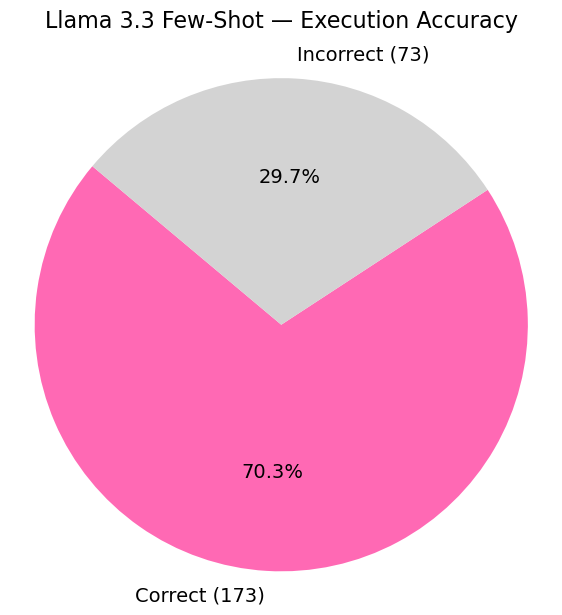

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load few-shot results
df = pd.read_csv("results/llama3_fewshot_FULL_results.csv")

# 2. Count Correct (1) and Incorrect (0) queries
score_counts = df['Execution Score'].value_counts()
correct_count   = score_counts.get(1, 0)
incorrect_count = score_counts.get(0, 0)

# 3. Set up labels and colors
labels = [f'Correct ({correct_count})', f'Incorrect ({incorrect_count})']
sizes  = [correct_count, incorrect_count]
colors = ['hotpink', '#d3d3d3']

# 4. Create the Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 14})
plt.title('Llama 3.3 Few-Shot — Execution Accuracy', fontsize=16, pad=20)
plt.axis('equal')

plt.savefig('accuracy_pie_chart.png', bbox_inches='tight', dpi=300)
print("Chart saved as 'accuracy_pie_chart.png'!")
plt.show()

## Bar Chart

Bar chart saved as 'accuracy_bar_chart.png'!


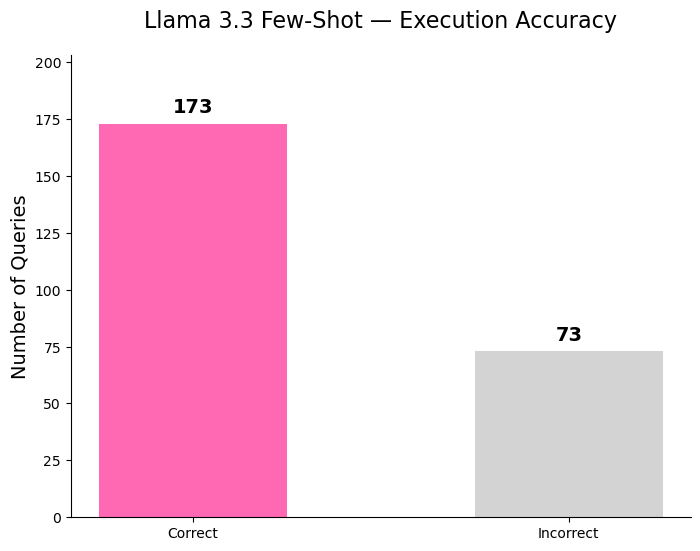

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load few-shot results
df = pd.read_csv("results/llama3_fewshot_FULL_results.csv")

# 2. Count Correct and Incorrect
score_counts = df['Execution Score'].value_counts()
correct_count   = score_counts.get(1, 0)
incorrect_count = score_counts.get(0, 0)

categories = ['Correct', 'Incorrect']
counts = [correct_count, incorrect_count]
colors = ['hotpink', '#d3d3d3']

# 3. Create the Bar Chart
plt.figure(figsize=(8, 6))
bars = plt.bar(categories, counts, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 3,
             str(int(height)), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.title('Llama 3.3 Few-Shot — Execution Accuracy', fontsize=16, pad=20)
plt.ylabel('Number of Queries', fontsize=14)
plt.ylim(0, max(counts) + 30)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('accuracy_bar_chart.png', bbox_inches='tight', dpi=300)
print("Bar chart saved as 'accuracy_bar_chart.png'!")
plt.show()

In [72]:
import pandas as pd

df_fs = pd.read_csv("results/llama3_fewshot_FULL_results.csv")
fs_errors = df_fs[df_fs['Execution Score'] == 0]

print(f"Total errors: {len(fs_errors)}\n")
print("--- All errors with query ---")
for _, row in fs_errors.iterrows():
    print(f"\nQ:    {row['Question Text']}")
    print(f"GOLD: {str(row['Truth Query'])[:120]}")
    print(f"LLM:  {str(row['LLM Query'])[:120]}")
    print(f"ERR:  {row['Error_Message']}")
    print("-" * 60)

Total errors: 73

--- All errors with query ---

Q:    name the major lakes in michigan
GOLD: SELECT LAKEalias0.LAKE_NAME FROM LAKE AS LAKEalias0 WHERE LAKEalias0.AREA > 750 AND LAKEalias0.STATE_NAME = "california"
LLM:  SELECT lake_name FROM lake WHERE area > 750 AND state_name = 'michigan'
ERR:  Data Mismatch
------------------------------------------------------------

Q:    what is the highest point in each state whose lowest point is sea level
GOLD: SELECT HIGHLOWalias0.HIGHEST_POINT , HIGHLOWalias0.STATE_NAME FROM HIGHLOW AS HIGHLOWalias0 WHERE HIGHLOWalias0.LOWEST_E
LLM:  SELECT highest_point FROM highlow WHERE lowest_elevation = 0
ERR:  Data Mismatch
------------------------------------------------------------

Q:    name all the rivers in colorado
GOLD: SELECT RIVERalias0.RIVER_NAME FROM RIVER AS RIVERalias0 WHERE RIVERalias0.TRAVERSE = "texas" ;
LLM:  SELECT river_name FROM river WHERE traverse = 'colorado'
ERR:  Data Mismatch
-------------------------------------------------

### Case Categories

**Major threshold** — uses `LIMIT` or a 100,000 threshold instead of 150,000/7,501,622 -> cases: 16 or 22.5%

**Incorrect complex subquery** — wrong nested logic -> cases: 16 or 22.5%

**Unnecessary country_name filter** — adds `WHERE country_name` where it is not needed -> cases: 9 or 12.7%

**Wrong table** — uses `mountain` instead of `highlow`, `state` instead of `city` -> cases: 7 or 9.9%

**Wrong column** — uses `state_name` instead of `traverse`, `elevation` instead of `point` -> cases: 5 or 7% 

**Extra columns returned** — returns `state_name` in addition to what the gold query requires -> cases: 4 or 5.6% 

**Broken gold query** — bug in the dataset itself, not a model error -> cases: 4 or 5.6%  -> **out of 68 errors, the model actually made a mistake 64 times**

**Wrong string value** — searches for "mount mckinley" instead of "mckinley" -> cases: 16 or 22.5% 

**Other** -> 11.3%

## Chain Of Thought

### Part 1: "Re-Setup" and the Prompt

This code block defines the "Golden Prompt": a highly structured set of instructions that tells the AI exactly how to behave.

- The Persona & Schema: It tells the AI it is an "expert SQL developer" and provides the exact database tables and columns. This prevents the AI from hallucinating or guessing table names.

- The Rules: It sets strict boundaries (like only using lowercase names and wrapping the final code in sql tags) so the output is clean and won't crash the database.

- Chain of Thought (CoT): By forcing the AI to write a "Thought Process" before it writes the code, it will slow down and plan its logic step-by-step. This drastically reduces errors on complex questions.

- The Example (Few-Shot): It gives the AI a perfect example of how to format its answer, showing it exactly what a successful "Thought Process" and SQL block look like.

- The Placeholder ({user_question}): This is the blank space at the very end. Later in the code, Python will swap out {user_question} with a real question from the database, triggering the AI to start thinking and answer it.

In [105]:
# CoT RE-SETUP
import pandas as pd
import sqlite3
from groq import Groq
from dotenv import load_dotenv
import os

# 1. Connect to the AI (Groq)
load_dotenv("api.env")
client = Groq(api_key=os.getenv("GROQ_API_KEY"))

# 2. Reconnect to the Database
conn = sqlite3.connect("geography-db.added-in-2020.sqlite")
cursor = conn.cursor()

# Note: we iterate directly over 'dataset' (already loaded in Part 3)
# so no need to reload a CSV here.
print("Setup complete! Ready for Chain-of-Thought evaluation.")
print(f"Dataset size: {len(dataset)} questions")

Setup complete! Ready for Chain-of-Thought evaluation.
Dataset size: 246 questions


In [106]:
cot_few_shot_prompt = """You are an expert SQL developer querying a SQLite Geography database.
Translate the natural language question into a valid SQLite query.

### EXACT Database Schema (all lowercase):
- state (state_name, population, area, country_name, capital, density)
- border_info (state_name, border)
- city (city_name, population, country_name, state_name)
- highlow (state_name, highest_elevation, lowest_point, highest_point, lowest_elevation)
- river (river_name, length, country_name, traverse)
- mountain (mountain_name, mountain_altitude, country_name, state_name)
- lake (lake_name, area, country_name, state_name)

### CRITICAL DOMAIN RULES (memorize before every query):
1. "major city"  = population > 150000. NEVER use LIMIT, return ALL rows.
2. "major river" = length > 750.        NEVER use LIMIT, return ALL rows.
3. "major lake"  = area > 750.          NEVER use LIMIT, return ALL rows.
4. Rivers: use 'traverse' to filter by state. Use 'country_name' ONLY if the question
   explicitly says "in the US/USA/united states".
5. "sea level" = lowest_elevation = 0.
6. Mountain elevation: use 'highlow.highest_elevation', NOT 'mountain.mountain_altitude'.
7. Mountain name lookup: search for the SHORT name (e.g. 'mckinley' not 'mount mckinley').
8. NEVER return extra columns — return ONLY what the question asks for.
9. NEVER add WHERE country_name unless the question explicitly mentions a country.
10. Always think step-by-step before writing SQL. Wrap final SQL in ```sql ... ``` tags.
11. 'capital' is a column in the 'state' table. To find a state by its capital,
    use: WHERE state.capital = 'albany'. NEVER JOIN with city UNLESS the question asks for the population/size of the capital city itself.
12. For superlatives across all rows (largest city in the US), ALWAYS use:
    WHERE population = (SELECT MAX(population) FROM city)
    NEVER use ORDER BY ... LIMIT 1 for cross-state superlatives.

### EXAMPLES:

-- Example 1: superlative within a state, use subquery
Question: "What is the largest city in texas?"
Thought Process:
1. Need the city with highest population in texas.
2. Table: city. Filter by state_name = 'texas'.
3. Superlative → use WHERE population = (SELECT MAX(population)...)
   to ensure correctness even if multiple cities tie for the max.
4. Return only city_name.
```sql
SELECT city_name FROM city WHERE population = (SELECT MAX(population) FROM city WHERE state_name = 'texas') AND state_name = 'texas'
```

-- Example 2: "major" = threshold, NO LIMIT
Question: "What are the major cities in florida?"
Thought Process:
1. "Major city" means population > 150000 — a threshold, not a ranking.
2. Table: city. Filter: state_name = 'florida' AND population > 150000.
3. Return ALL matching rows, no LIMIT.
4. Return only city_name.
```sql
SELECT city_name FROM city WHERE population > 150000 AND state_name = 'florida'
```

-- Example 3: rivers use 'traverse' for state, NOT country_name
Question: "Name all the rivers in colorado."
Thought Process:
1. Table: river. Rivers are linked to states via 'traverse', not 'country_name'.
2. Filter: traverse = 'colorado'.
3. Return only river_name.
```sql
SELECT river_name FROM river WHERE traverse = 'colorado'
```

-- Example 4: subquery for superlative across all rows
Question: "Which states does the longest river run through?"
Thought Process:
1. Need MAX(length) first via subquery.
2. Return traverse (the states) for that river.
3. No country filter — question doesn't mention a country.
```sql
SELECT traverse FROM river WHERE length = (SELECT MAX(length) FROM river)
```

-- Example 5: mountain elevation uses highlow, not mountain table
Question: "What is the height of the highest mountain in texas?"
Thought Process:
1. Elevation data is in highlow, not mountain.
2. Filter: state_name = 'texas'.
3. Superlative → MAX(DISTINCT highest_elevation).
```sql
SELECT MAX(DISTINCT highest_elevation) FROM highlow WHERE state_name = 'texas'
```

-- Example 6: nested border subquery
Question: "What states border states that border texas?"
Thought Process:
1. First find all states that border texas: SELECT border FROM border_info WHERE state_name = 'texas'.
2. Then find states that border any of those states.
3. Return border column (the neighboring states).
```sql
SELECT border FROM border_info WHERE state_name IN (SELECT border FROM border_info WHERE state_name = 'texas')
```

-- Example 7: capital lookup uses state.capital directly, no JOIN
Question: "What is the area of the state with the capital albany?"
Thought Process:
1. Capital info is in state.capital — no JOIN needed.
2. Filter: state.capital = 'albany'.
3. Return only area.
```sql
SELECT area FROM state WHERE capital = 'albany'
```

### YOUR TURN:
Question: "{user_question}"
Thought Process:
"""

## Part 2: Evaluating the LLM on 10 questions

This code is an automated testing loop that evaluates how well the AI translates natural language questions into SQL queries using the Chain of Thought prompt.

Here is a brief summary of the 5 steps it performs:

- Setup: It grabs a small test batch of 10 questions from the dataset.

- AI Generation: It loops through those 10 questions, plugging each one into the prompt, and sends it to the AI.

- The Parser: When the AI responds with its "Thought Process" and SQL, the script cuts out the English text and saves only the raw SQL code.

- Execution & Grading: It runs the AI's SQL in the database and compares the data it pulls back to the "Gold Standard" (Truth Query) data. If they match exactly, it gives the AI a score of 1. If the code crashes or pulls the wrong data, it gets a 0.

- Results: It calculates the final accuracy percentage and saves everything (including the AI's thoughts) to a CSV file so it can be reviewed.

In [41]:
import time

PROBE_SIZE = 10
cot_probe_results = []

print(f"Starting Chain-of-Thought Probe ({PROBE_SIZE} questions)...\n")

for i, item in enumerate(dataset[:PROBE_SIZE]):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = cot_few_shot_prompt.format(user_question=question)

    start_time   = time.time()
    success      = False
    retries      = 0
    raw_response = ""
    llm_query    = "API_ERROR"

    while not success and retries < 3:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0,
            )
            raw_response = chat_completion.choices[0].message.content.strip()
            if "```sql" in raw_response:
                llm_query = raw_response.split("```sql")[-1].split("```")[0].strip()
            else:
                llm_query = raw_response.strip()
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit. Waiting 60s... (attempt {retries+1}/3)")
                time.sleep(60)
                retries += 1
            else:
                llm_query = f"API_ERROR: {e}"
                success = True

    generation_time = time.time() - start_time

    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0

    truth_result    = []
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    execution_score = 0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result    = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    cot_probe_results.append({
        "Question ID":         i + 1,
        "Question Text":       question,
        "Truth Query":         truth_query,
        "Raw AI Thought":      raw_response,
        "LLM Query":           llm_query,
        "Generation Time (s)": round(generation_time, 3),
        "Truth Exec Time (s)": round(truth_exec_time, 4),
        "LLM Exec Time (s)":   round(llm_exec_time, 4),
        "String Match":        string_match_score,
        "Execution Score":     execution_score,
        "Error_Message":       error_msg
    })

    status = "✓" if execution_score else "✗"
    print(f"  [{status}] Q{i+1}: {question[:55]}...")

probe_acc = sum(r['Execution Score'] for r in cot_probe_results) / PROBE_SIZE * 100
print(f"\n{'='*50}")
print(f"CoT PROBE COMPLETE")
print(f"Accuracy: {sum(r['Execution Score'] for r in cot_probe_results)}"
      f"/{PROBE_SIZE} = {probe_acc:.1f}%")

Starting Chain-of-Thought Probe (10 questions)...

  [✓] Q1: what is the biggest city in arizona...
  [✓] Q2: which rivers run through the state with the largest cit...
  [✓] Q3: how big is texas...
  [✓] Q4: how many people live in washington...
  [✓] Q5: what state has the smallest population...
  [✓] Q6: give me the cities in virginia...
  [✓] Q7: what is the area of the state with the capital albany...
  [✓] Q8: give me the lakes in california...
  [✗] Q9: name the major lakes in michigan...
  [✓] Q10: what are the states...

CoT PROBE COMPLETE
Accuracy: 9/10 = 90.0%


Which errors where made? See below

In [43]:
import pandas as pd

for r in cot_probe_results:
    if r['Execution Score'] == 0:
        print(f"Q:     {r['Question Text']}")
        print(f"GOLD:  {r['Truth Query']}")
        print(f"LLM:   {r['LLM Query']}")
        print(f"ERR:   {r['Error_Message']}")

Q:     name the major lakes in michigan
GOLD:  SELECT LAKEalias0.LAKE_NAME FROM LAKE AS LAKEalias0 WHERE LAKEalias0.AREA > 750 AND LAKEalias0.STATE_NAME = "california" ;
LLM:   SELECT lake_name FROM lake WHERE area > 750 AND state_name = 'michigan'
ERR:   Data Mismatch


### Q9

This is a **dataset annotation error**, not a model failure. The LLM correctly interpreted the question — it applied the right "major lake" threshold (area > 750) and filtered by the correct state (michigan). However, the gold query in the GeoQuery dataset maps the question to california instead, which is factually inconsistent with the natural language question.

This type of error is a known limitation of the GeoQuery benchmark. Because the dataset was originally built using a formal logical representation (lambda calculus) and later converted to SQL, some variable substitutions were incorrectly applied during the conversion process, resulting in gold queries that do not match the corresponding natural language question.

For evaluation purposes, this query is marked as incorrect (Execution Score = 0), but it should be classified as a false negative — a case where the model produced a semantically correct answer that is penalized due to a ground truth annotation error. Across the full dataset, 4 such cases were identified, representing an inherent ceiling on achievable accuracy that cannot be overcome through prompt engineering alone.

## Part 3: Full run of Chain of Thought

This code is an automated testing pipeline that grades how well the AI model translates 246 natural language questions into SQL database queries.

Here is exactly what it does in 4 steps:

- Prompts the AI: It loops through the dataset and asks the AI to solve each of the 246 questions using the "Chain of Thought" instructions.

- Extracts the Code: It automatically cuts out the SQL code from the AI's response and handles any API rate limits along the way.

- Grades the Answer: It runs both the AI's code and thr "Gold Standard" code in the database. If the AI pulls the exact same data as the Gold Standard, it gets a pass (1); otherwise, it fails (0).

- Calculates & Saves: It calculates the final accuracy percentage and saves a detailed Excel/CSV file with every single question, the AI's thoughts, and its pass/fail score.

In [ ]:
import time
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

total_tested          = len(dataset)
total_string_match    = 0
total_execution_match = 0
cot_results           = []

print(f"STARTING FULL CoT EVALUATION ({total_tested} Questions)")
print("Model: llama-3.3-70b-versatile | Strategy: Chain-of-Thought\n")

for i, item in enumerate(dataset):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = cot_few_shot_prompt.format(user_question=question)

    start_time   = time.time()
    success      = False
    retries      = 0
    raw_response = ""
    llm_query    = "API_ERROR"

    while not success and retries < 3:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0,
            )
            raw_response = chat_completion.choices[0].message.content.strip()
            if "```sql" in raw_response:
                llm_query = raw_response.split("```sql")[-1].split("```")[0].strip()
            else:
                llm_query = raw_response.strip()
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit Hit. Waiting 90s... (attempt {retries+1}/3)")
                time.sleep(90)
                retries += 1
            else:
                llm_query    = "API_ERROR"
                raw_response = str(e)
                success      = True

    time.sleep(3)
    generation_time = time.time() - start_time

    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0
    if string_match_score:
        total_string_match += 1

    truth_result    = []
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    execution_score = 0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result    = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
            total_execution_match += 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    cot_results.append({
        "Question ID":         i + 1,
        "Question Text":       question,
        "Truth Query":         truth_query,
        "Raw AI Thought":      raw_response,
        "LLM Query":           llm_query,
        "Generation Time (s)": round(generation_time, 3),
        "Truth Exec Time (s)": round(truth_exec_time, 4),
        "LLM Exec Time (s)":   round(llm_exec_time, 4),
        "String Match":        string_match_score,
        "Execution Score":     execution_score,
        "Error_Message":       error_msg
    })

    if (i + 1) % 25 == 0:
        pd.DataFrame(cot_results).to_csv(
            "results/llama3_cot_FULL_results.csv", index=False)

    if (i + 1) % 25 == 0 or (i + 1) == total_tested:
        current_acc = total_execution_match / (i + 1) * 100
        print(f"  Processed {i+1}/{total_tested} | Accuracy so far: {current_acc:.1f}%")

cot_df = pd.DataFrame(cot_results)
output_path = "results/llama3_cot_FULL_results.csv"
cot_df.to_csv(output_path, index=False)

print(f"\n{'='*50}")
print(f"CoT COMPLETE")
print(f"String Match:       {total_string_match}/{total_tested}")
print(f"Execution Accuracy: {total_execution_match}/{total_tested} = "
      f"{total_execution_match/total_tested*100:.1f}%")

Unfortunately, this code had difficulty when runing the 246 questions of CoT because of the few API calls available due to its complexity; We decided to implement a new code, where we can manually put the range of questions preferred and the results are saved every 10 question (in case of "Rate Limit Hit").

## Batch-Based Resume Strategy

Due to the API rate limits imposed by the Groq free tier (30 requests/minute, 1000 requests/day), the full 246-question evaluation cannot always be completed in a single session. To handle this, a batch-based resume strategy was implemented.

Instead of running all remaining questions at once, each session processes a fixed range of questions defined by BATCH_START and BATCH_END. At the start of each session, the code loads the CSV file containing all previously completed questions (or it creates a new one if it does not find one already existing), identifies which Question IDs have already been answered, and runs only the questions within the specified batch range that have not yet been processed.

Progress is saved to the same CSV file every 10 questions (checkpoint), so no work is lost if the session is interrupted. The time.sleep(3) between each API call keeps the request rate at ~20 requests/minute, safely below the 30 req/min limit.

To continue across sessions, only two numbers need to be updated at the top of the cell:
- BATCH_START: the first question ID of the current session
- BATCH_END:   the last question ID of the current session

The final print statement automatically suggests the correct values for the next session.
This approach guarantees that the final CSV contains all 246 questions in order, regardless of how many sessions were needed to complete the evaluation.

In [107]:
import time, os
import pandas as pd

os.makedirs("results", exist_ok=True)

# Change these two numbers each session 
BATCH_START = 191    # first question of this batch
BATCH_END   = 246   # last question of this batch

csv_path = "results/llama3_cot_FULL_results.csv"

# Load existing CSV or create empty one
if os.path.exists(csv_path):
    df_partial = pd.read_csv(csv_path)
else:
    df_partial = pd.DataFrame(columns=[
        "Question ID", "Question Text", "Truth Query", "Raw AI Thought",
        "LLM Query", "Generation Time (s)", "Truth Exec Time (s)",
        "LLM Exec Time (s)", "String Match", "Execution Score", "Error_Message"
    ])
    df_partial.to_csv(csv_path, index=False)

print(f"Model: llama-3.3-70b-versatile | Strategy: Chain-of-Thought")
print(f"Already done: {len(df_partial)}/246")
print(f"This session: questions {BATCH_START} to {BATCH_END}\n")

done_ids        = set(df_partial['Question ID'].tolist()) if len(df_partial) > 0 else set()
remaining_items = [(i+1, item) for i, item in enumerate(dataset)
                   if (i+1) not in done_ids
                   and BATCH_START <= (i+1) <= BATCH_END]

print(f"Questions to run this session: {len(remaining_items)}\n")

total_correct = int(df_partial['Execution Score'].sum()) if len(df_partial) > 0 else 0
total_so_far  = len(df_partial)

for count, (q_id, item) in enumerate(remaining_items, 1):
    question    = resolve_question(item)
    truth_query = resolve_gold_sql(item)

    final_prompt = cot_few_shot_prompt.format(user_question=question)

    start_time   = time.time()
    success      = False
    retries      = 0
    llm_query    = "API_ERROR"
    raw_response = ""

    while not success and retries < 5:
        try:
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": final_prompt}],
                model="llama-3.3-70b-versatile",
                temperature=0.0
            )
            raw_response = chat_completion.choices[0].message.content.strip()
            if "```sql" in raw_response:
                llm_query = raw_response.split("```sql")[-1].split("```")[0].strip()
            else:
                llm_query = raw_response.strip()
            success = True
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  Rate Limit Hit. Waiting 90s... (attempt {retries+1}/5)")
                time.sleep(90)
                retries += 1
            else:
                llm_query    = "API_ERROR"
                raw_response = str(e)
                success      = True

    time.sleep(3)
    generation_time    = time.time() - start_time
    string_match_score = 1 if llm_query.lower() == truth_query.lower() else 0

    truth_result    = []
    truth_exec_time = 0.0
    llm_exec_time   = 0.0
    execution_score = 0
    error_msg       = ""

    try:
        t0 = time.perf_counter()
        cursor.execute(truth_query)
        truth_result    = cursor.fetchall()
        truth_exec_time = time.perf_counter() - t0
    except Exception as e:
        truth_result    = []
        truth_exec_time = 0.0
        error_msg       = f"Gold SQL Error: {e}"

    try:
        t0 = time.perf_counter()
        cursor.execute(llm_query)
        llm_result    = cursor.fetchall()
        llm_exec_time = time.perf_counter() - t0

        if set(llm_result) == set(truth_result):
            execution_score = 1
        else:
            if not error_msg:
                error_msg = "Data Mismatch"
    except Exception as e:
        error_msg = f"SQL Error: {e}"

    total_correct += execution_score
    total_so_far  += 1

    new_row = pd.DataFrame([{
        "Question ID":         q_id,
        "Question Text":       question,
        "Truth Query":         truth_query,
        "Raw AI Thought":      raw_response,
        "LLM Query":           llm_query,
        "Generation Time (s)": round(generation_time, 3),
        "Truth Exec Time (s)": round(truth_exec_time, 4),
        "LLM Exec Time (s)":   round(llm_exec_time, 4),
        "String Match":        string_match_score,
        "Execution Score":     execution_score,
        "Error_Message":       error_msg
    }])
    df_partial = pd.concat([df_partial, new_row], ignore_index=True)

    # checkpoint every 10 questions
    if count % 10 == 0:
        df_partial.to_csv(csv_path, index=False)
        current_acc = total_correct / total_so_far * 100
        print(f"  Processed {total_so_far}/246 | Accuracy so far: {current_acc:.1f}%")

df_partial = df_partial.sort_values('Question ID').reset_index(drop=True)
df_partial.to_csv(csv_path, index=False)
total_ok = df_partial['Execution Score'].sum()
print(f"\n{'='*50}")
print(f"SESSION COMPLETE — {len(df_partial)}/246 total")
print(f"Accuracy so far: {total_ok}/{len(df_partial)} = {total_ok/len(df_partial)*100:.1f}%")
print(f"Next session: set BATCH_START={BATCH_END + 1}, BATCH_END={BATCH_END + 50}")
print(f"Saved to: {csv_path}")

Model: llama-3.3-70b-versatile | Strategy: Chain-of-Thought
Already done: 190/246
This session: questions 191 to 246

Questions to run this session: 56

  Processed 200/246 | Accuracy so far: 77.5%
  Processed 210/246 | Accuracy so far: 78.1%
  Processed 220/246 | Accuracy so far: 77.7%
  Processed 230/246 | Accuracy so far: 77.0%
  Processed 240/246 | Accuracy so far: 77.1%

SESSION COMPLETE — 246/246 total
Accuracy so far: 191/246 = 77.6%
Next session: set BATCH_START=247, BATCH_END=296
Saved to: results/llama3_cot_FULL_results.csv


## Comparative Analysis: All Prompt Strategies

This section compares the three prompt strategies head-to-head on all key metrics:
Execution Accuracy, VES, Generation Time, and Error Distribution.

### Step 1: Load Results

All three CSV result files are loaded into a shared dictionary (`dataframes`).
All subsequent cells read from this dictionary, so this cell must be run first.
The central file registry (`FILES`) makes it easy to update paths in one place.

In [3]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Central file registry — edit only here if paths change
FILES = {
    "Zero-Shot":        "results/llama3_zeroshot_FULL_results.csv",
    "Few-Shot":         "results/llama3_fewshot_FULL_results.csv",
    "Chain-of-Thought": "results/llama3_cot_FULL_results.csv",
}
SQL_COL = "LLM Query"  # same column name across all three strategies
COLORS  = ["#FF69B4", "#FF1493", "#C71585"]

dataframes = {}
for name, path in FILES.items():
    try:
        dataframes[name] = pd.read_csv(path)
        print(f"  ✓ {name}: {len(dataframes[name])} rows loaded")
    except FileNotFoundError:
        print(f"  ✗ {name}: file not found — run the full evaluation first")

print("\nAll files loaded." if len(dataframes) == 3 else "\nSome files are missing.")

  ✓ Zero-Shot: 246 rows loaded
  ✓ Few-Shot: 246 rows loaded
  ✓ Chain-of-Thought: 246 rows loaded

All files loaded.


## VES: Valid Efficiency Score

### Step 2: Valid Efficiency Score (VES)

VES measures how efficiently the AI's query retrieves data compared to the gold standard.
- Formula: sqrt(time_gold / time_ai), capped at 200%
- Queries with Execution Score = 0 automatically receive VES = 0
- Both times are floored at 1e-6 seconds to avoid division-by-zero on fast SQLite queries

A VES above 100% means the AI wrote a faster query than the gold standard.
A VES below 100% means the AI's query was slower.
The final table shows Execution Accuracy and VES side by side for all three strategies.

In [119]:
def calculate_ves(df, sql_col):
    """
    Calculates VES for each query.
    - Queries with Execution Score = 0 receive VES = 0.
    - Formula: sqrt(time_gold / time_ai), capped at 2.0 (200%).
    - Both times floored at 1e-6 to avoid division by zero.
    """
    ves_scores = []

    for _, row in df.iterrows():
        if row['Execution Score'] == 0:
            ves_scores.append(0.0)
            continue

        llm_sql  = str(row[sql_col])
        gold_sql = str(row['Truth Query'])

        try:
            t0 = time.perf_counter()
            cursor.execute(llm_sql)
            cursor.fetchall()
            time_ai = max(time.perf_counter() - t0, 1e-6)

            t0 = time.perf_counter()
            cursor.execute(gold_sql)
            cursor.fetchall()
            time_gold = max(time.perf_counter() - t0, 1e-6)

            ves = np.sqrt(time_gold / time_ai)
            ves_scores.append(min(ves, 2.0))
        except Exception:
            ves_scores.append(0.0)

    return ves_scores


print("Calculating VES...\n")
summary = []

for name, df in dataframes.items():
    ves_scores = calculate_ves(df, SQL_COL)
    df['VES']  = ves_scores

    acc     = df['Execution Score'].mean() * 100
    ves_avg = (sum(ves_scores) / len(ves_scores)) * 100

    summary.append({
        "Strategy":           name,
        "Questions":          len(df),
        "Execution Accuracy": f"{acc:.1f}%",
        "VES":                f"{ves_avg:.1f}%",
    })

    out = f"results/llama3_{name.lower().replace('-','').replace(' ','_')}_WITH_VES.csv"
    df.to_csv(out, index=False)
    print(f"  {name}: Accuracy={acc:.1f}% | VES={ves_avg:.1f}% | saved to {out}")

print(f"\n{'='*55}")
print(f"{'FINAL COMPARISON':^55}")
print(f"{'='*55}")
print(pd.DataFrame(summary).to_string(index=False))
print(f"{'='*55}")

Calculating VES...

  Zero-Shot: Accuracy=60.6% | VES=56.5% | saved to results/llama3_zeroshot_WITH_VES.csv
  Few-Shot: Accuracy=70.3% | VES=72.1% | saved to results/llama3_fewshot_WITH_VES.csv
  Chain-of-Thought: Accuracy=77.6% | VES=76.5% | saved to results/llama3_chainofthought_WITH_VES.csv

                   FINAL COMPARISON                    
        Strategy  Questions Execution Accuracy   VES
       Zero-Shot        246              60.6% 56.5%
        Few-Shot        246              70.3% 72.1%
Chain-of-Thought        246              77.6% 76.5%


## Chart: Execution Accuracy vs String Match

### Step 3: Accuracy Comparison Chart

This chart compares Execution Accuracy and String Match side by side for each strategy.
- Execution Accuracy: the query produces the correct result when run on the database
- String Match: the query is character-for-character identical to the gold standard

String Match is expected to be near 0% for all strategies, since the LLM generates
semantically equivalent but syntactically different SQL — which is the correct behavior.

Chart saved: results/comparison_accuracy.png


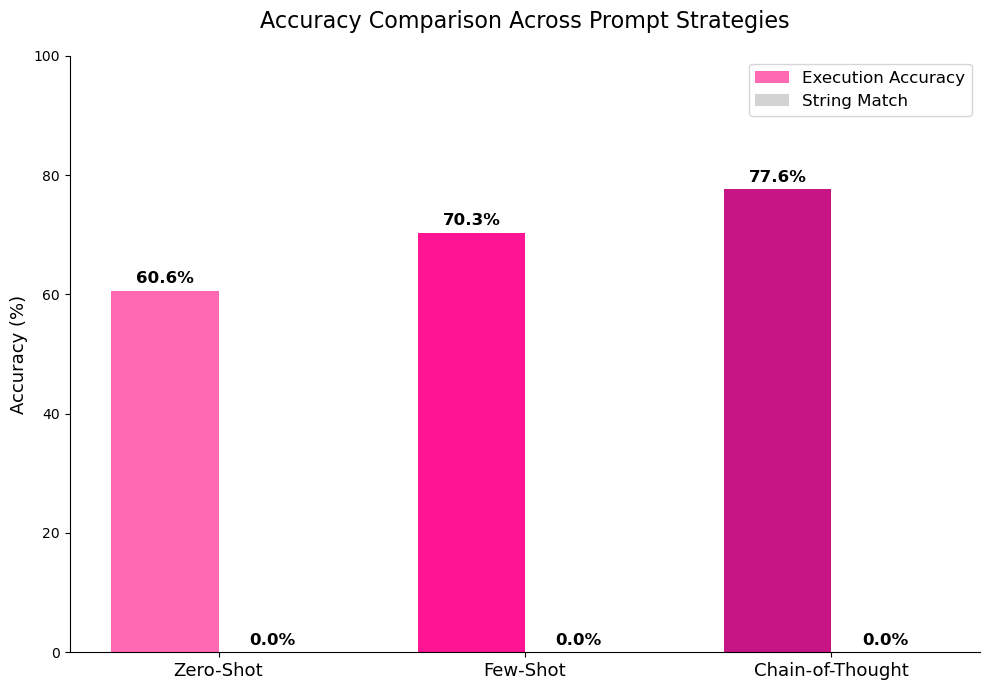


SUMMARY TABLE
Strategy               Exec Acc   String Match   Total Q
--------------------------------------------------------
Zero-Shot                 60.6%           0.0%       246
Few-Shot                  70.3%           0.0%       246
Chain-of-Thought          77.6%           0.0%       246


In [120]:
strategies, exec_accs, str_matches, totals = [], [], [], []

for name, df in dataframes.items():
    n = len(df)
    strategies.append(name)
    exec_accs.append(round(df['Execution Score'].sum() / n * 100, 1))
    str_matches.append(round(df['String Match'].sum() / n * 100, 1)
                       if 'String Match' in df.columns else 0.0)
    totals.append(n)

x     = np.arange(len(strategies))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 7))

bars1 = ax.bar(x - width/2, exec_accs,   width, label='Execution Accuracy', color=COLORS)
bars2 = ax.bar(x + width/2, str_matches, width, label='String Match',
               color=['#d3d3d3', '#b0b0b0', '#909090'])

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f"{h:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_ylim(0, 100)
ax.set_title('Accuracy Comparison Across Prompt Strategies', fontsize=16, pad=20)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/comparison_accuracy.png', bbox_inches='tight', dpi=300)
print("Chart saved: results/comparison_accuracy.png")
plt.show()

print("\nSUMMARY TABLE")
print(f"{'Strategy':<20} {'Exec Acc':>10} {'String Match':>14} {'Total Q':>9}")
print("-" * 56)
for i, name in enumerate(strategies):
    print(f"{name:<20} {exec_accs[i]:>9.1f}% {str_matches[i]:>13.1f}% {totals[i]:>9}")

## Chart: VES Comparison

### Step 4: VES Comparison Chart

This chart visualizes the Valid Efficiency Score for each prompt strategy.
VES captures not just whether the answer is correct, but how efficiently it was retrieved.
It complements Execution Accuracy by penalizing unnecessarily slow or complex queries.

Chart saved: results/comparison_ves.png


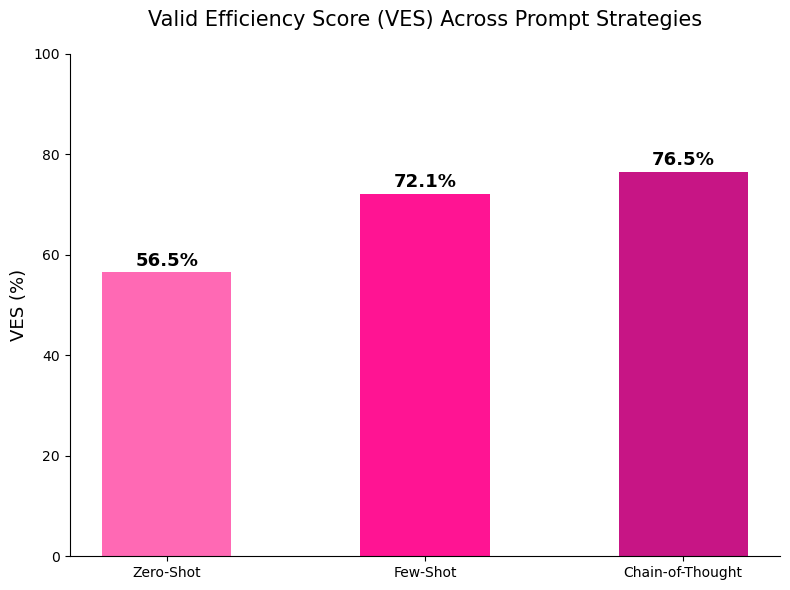

In [121]:
ves_avgs = []
for name, df in dataframes.items():
    ves_avgs.append(round(df['VES'].mean() * 100, 1) if 'VES' in df.columns else 0.0)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(list(dataframes.keys()), ves_avgs, color=COLORS, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f"{h:.1f}%", ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('VES (%)', fontsize=13)
ax.set_ylim(0, 100)
ax.set_title('Valid Efficiency Score (VES) Across Prompt Strategies', fontsize=15, pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/comparison_ves.png', bbox_inches='tight', dpi=300)
print("Chart saved: results/comparison_ves.png")
plt.show()

### Step 5: Latency Comparison Chart

This chart breaks down the three timing components recorded for every query:
- **Generation Time (s)**: how long the LLM takes to produce the SQL query (API call)
- **Truth Exec Time (s)**: how long SQLite takes to run the gold standard query
- **LLM Exec Time (s)**: how long SQLite takes to run the model-generated query

The generation time dominates by several orders of magnitude, illustrating the
classic latency bottleneck in LLM-based Text-to-SQL pipelines: the database answers
in microseconds, while the model thinks for seconds. The Truth and LLM execution
times are also compared separately, as their ratio is used to compute the VES metric.

Chart saved: results/comparison_latency.png


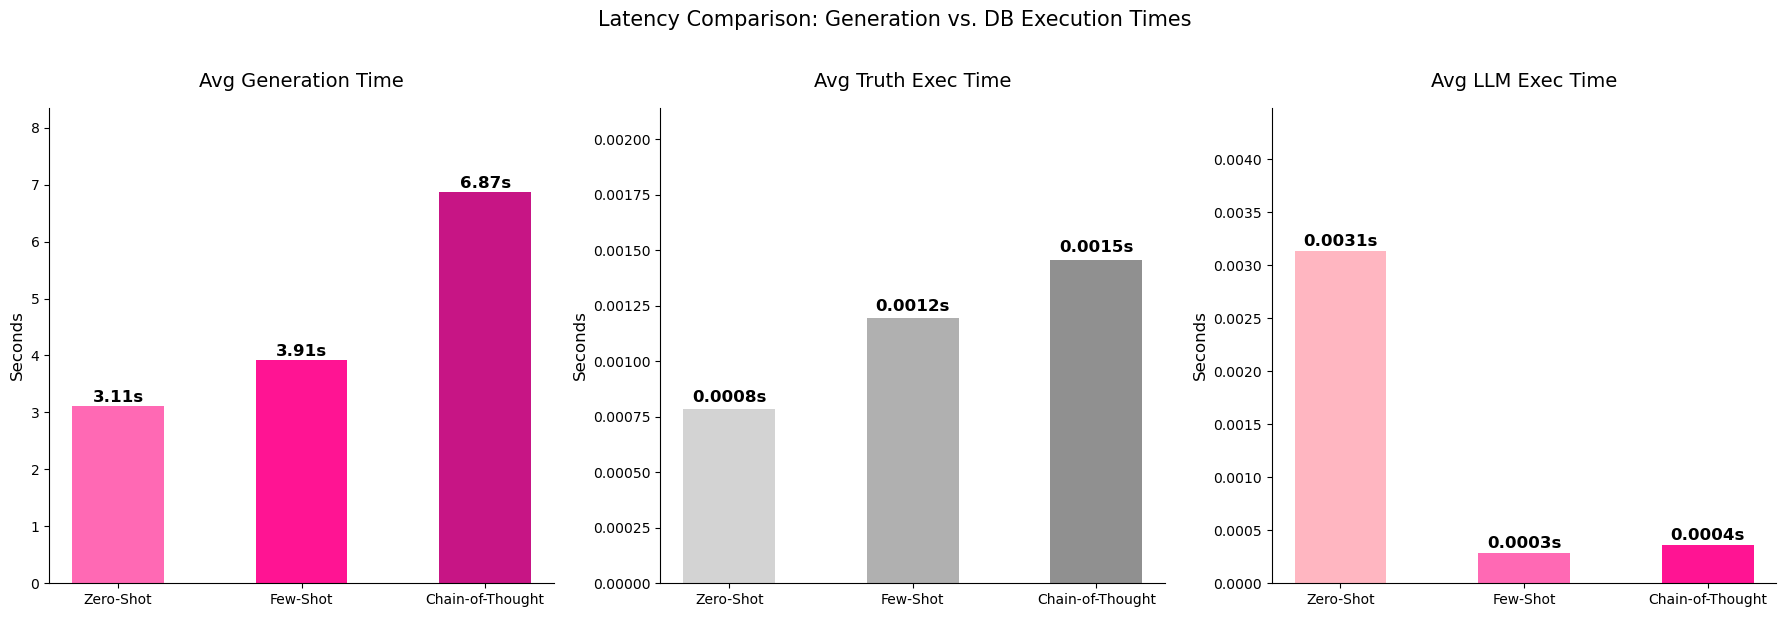


LATENCY SUMMARY
Strategy               Avg Gen Time   Truth Exec     LLM Exec
--------------------------------------------------------------
Zero-Shot                   3.108s     0.00078s     0.00313s
Few-Shot                    3.912s     0.00119s     0.00028s
Chain-of-Thought            6.873s     0.00146s     0.00036s


In [122]:
avg_gen_times   = []
avg_truth_times = []
avg_llm_times   = []

for name, df in dataframes.items():
    avg_gen_times.append(df['Generation Time (s)'].mean())
    avg_truth_times.append(df['Truth Exec Time (s)'].mean()
                           if 'Truth Exec Time (s)' in df.columns else 0.0)
    avg_llm_times.append(df['LLM Exec Time (s)'].mean()
                         if 'LLM Exec Time (s)' in df.columns else 0.0)

names = list(dataframes.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Average Generation Time
bars = axes[0].bar(names, avg_gen_times, color=COLORS, width=0.5)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                 f"{h:.2f}s", ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Avg Generation Time', fontsize=14, pad=15)
axes[0].set_ylabel('Seconds', fontsize=12)
axes[0].set_ylim(0, max(avg_gen_times) * 1.2 + 0.1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Middle: Average Truth Execution Time
bars2 = axes[1].bar(names, avg_truth_times,
                    color=['#d3d3d3', '#b0b0b0', '#909090'], width=0.5)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.00002,
                 f"{h:.4f}s", ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Truth Exec Time', fontsize=14, pad=15)
axes[1].set_ylabel('Seconds', fontsize=12)
axes[1].set_ylim(0, max(avg_truth_times) * 1.4 + 0.0001)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Right: Average LLM Execution Time
bars3 = axes[2].bar(names, avg_llm_times,
                    color=['#FFB6C1', '#FF69B4', '#FF1493'], width=0.5)
for bar in bars3:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h + 0.00002,
                 f"{h:.4f}s", ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[2].set_title('Avg LLM Exec Time', fontsize=14, pad=15)
axes[2].set_ylabel('Seconds', fontsize=12)
axes[2].set_ylim(0, max(avg_llm_times) * 1.4 + 0.0001)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle('Latency Comparison: Generation vs. DB Execution Times',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('results/comparison_latency.png', bbox_inches='tight', dpi=300)
print("Chart saved: results/comparison_latency.png")
plt.show()

print("\nLATENCY SUMMARY")
print(f"{'Strategy':<20} {'Avg Gen Time':>14} {'Truth Exec':>12} {'LLM Exec':>12}")
print("-" * 62)
for i, name in enumerate(names):
    print(f"{name:<20} {avg_gen_times[i]:>12.3f}s "
          f"{avg_truth_times[i]:>11.5f}s "
          f"{avg_llm_times[i]:>11.5f}s")

## Error categorization function

### Step 6: Error Categorization Function

This function assigns each failed query to one of seven error categories,
based on the manual error analysis conducted on the full result CSVs.
The categories reflect the actual failure patterns observed in the data,
replacing the generic JOIN/Aggregation/Subquery classification used in earlier versions.

The GeoQuery dataset contains 5 confirmed gold-query annotation errors.Two of them cause SQL execution failures (caught via "gold sql error"in the Error_Message). The remaining three execute correctly but return semantically wrong data because the gold query filters on the wrong entity (e.g. "michigan" -> filter "california"). These cases can only be identified by Question ID, so they are hardcoded below.


Categories:
- Major Threshold: model used LIMIT or wrong threshold instead of population/length/area cutoff
- Complex Subquery: incorrect nested SELECT logic
- Country Filter: added WHERE country_name filter not present in the gold query
- Wrong Table: used mountain instead of highlow, or state instead of city
- Extra Columns: returned more columns than the question asked for
- Dataset Bug: gold query is incorrect due to annotation errors in GeoQuery (excluded from chart)
- Other: uncategorized failures

Hardcoded Question IDs of confirmed GeoQuery gold-query annotation errors. These were identified via manual inspection of (question, gold, result) triples.

Semantic bugs (gold executes but filters on the wrong entity):
- QID  9: "name the major lakes in michigan" -> gold filters state_name='california'
- QID 19: "name all the rivers in colorado"  -> gold filters traverse='texas'
- QID 51: "what is the population of washington dc" -> gold filters city='minneapolis'

Execution bugs (gold crashes at runtime, also caught by "gold sql error"):
- QID  39: "which state borders most states" -> gold references missing alias
- QID 223: "how many rivers in texas are longer than the red" -> gold uses '> ALL' (not supported by SQLite)

In [5]:
KNOWN_DATASET_BUGS = {9, 19, 39, 51, 223}


def categorize_error(question, llm_query, gold_query, error_msg, qid=None):
    """
    Assigns each failed query to one of 7 error categories
    based on the actual error patterns found in the dataset.

    Parameters
    ----------
    question, llm_query, gold_query, error_msg : str
        Row fields from the result CSV.
    qid : int, optional
        Question ID. Required to detect the 3 semantic dataset bugs
        whose gold query executes successfully but returns wrong data.
    """
    q   = str(question).lower()
    llm = str(llm_query).lower()
    gld = str(gold_query).lower()
    err = str(error_msg).lower()

    # ---- Dataset Bug detection (priority over every other category) ----
    # 1) Hardcoded list of confirmed gold-annotation errors
    if qid is not None and int(qid) in KNOWN_DATASET_BUGS:
        return "Dataset Bug"
    # 2) Runtime fallback: gold query itself crashed during execution
    if "gold sql error" in err:
        return "Dataset Bug"

    # ---- Model error categories ----
    major_keywords = ["major city", "major cities", "major river",
                      "major rivers", "major lake", "major lakes"]
    if any(k in q for k in major_keywords):
        if "limit" in llm or ("150000" not in llm and "750" not in llm):
            return "Major Threshold"

    if "country_name" in llm and "country_name" not in gld:
        return "Country Filter"

    if "no such column" in err:
        return "Complex Subquery"

    llm_sel = llm.split("from")[0].replace("select", "").strip() if "from" in llm else ""
    gld_sel = gld.split("from")[0].replace("select", "").strip() if "from" in gld else ""
    if llm_sel.count(",") > gld_sel.count(","):
        return "Extra Columns"

    if ("mountain_altitude" in llm and "mountain_altitude" not in gld) or \
       ("from state" in llm and "capital" in q and "from city" in gld):
        return "Wrong Table"

    subquery_kw = ["select max", "select min", "select count",
                   "border_info", "group by", "not in", "in (select"]
    if any(k in llm for k in subquery_kw) or any(k in gld for k in subquery_kw):
        return "Complex Subquery"

    return "Other"


print("categorize_error() function ready.")
print(f"Tracking {len(KNOWN_DATASET_BUGS)} known dataset bugs: {sorted(KNOWN_DATASET_BUGS)}")

categorize_error() function ready.
Tracking 5 known dataset bugs: [9, 19, 39, 51, 223]


## Chart: Error breakdown comparison

### Step 7: Error Breakdown Chart

This chart shows how many failures fall into each error category per strategy.
Dataset bugs (gold query annotation errors) are excluded from the counts,
as they represent an inherent ceiling on achievable accuracy that no prompt
engineering technique can overcome.

Zero-Shot: 97 failures (5 excluded as dataset bugs, 92 real failures)
  Major Threshold: 12 (13.0%)
  Complex Subquery: 26 (28.3%)
  Country Filter: 28 (30.4%)
  Wrong Table: 7 (7.6%)
  Extra Columns: 16 (17.4%)
  Other: 3 (3.3%)

Few-Shot: 73 failures (5 excluded as dataset bugs, 68 real failures)
  Major Threshold: 1 (1.5%)
  Complex Subquery: 46 (67.6%)
  Country Filter: 8 (11.8%)
  Wrong Table: 8 (11.8%)
  Extra Columns: 0 (0.0%)
  Other: 5 (7.4%)

Chain-of-Thought: 55 failures (5 excluded as dataset bugs, 50 real failures)
  Major Threshold: 0 (0.0%)
  Complex Subquery: 21 (42.0%)
  Country Filter: 18 (36.0%)
  Wrong Table: 3 (6.0%)
  Extra Columns: 2 (4.0%)
  Other: 6 (12.0%)

Chart saved: results/comparison_errors.png


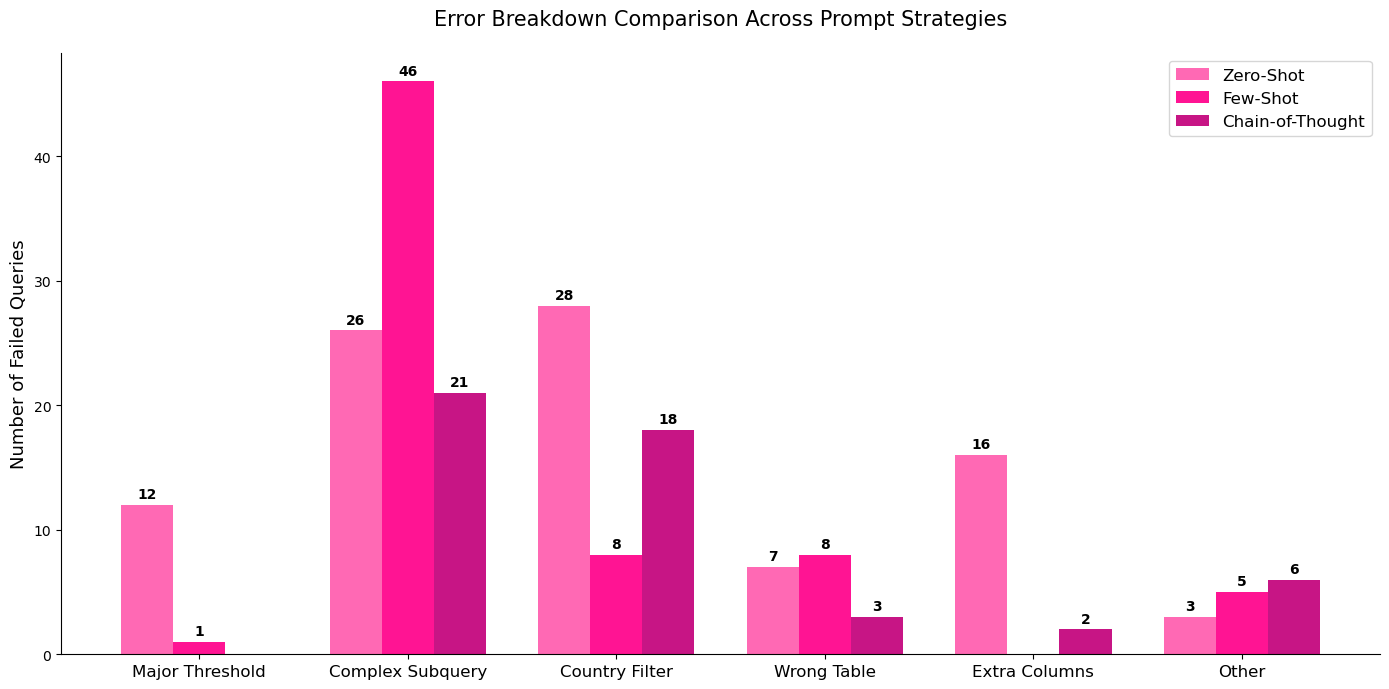

In [4]:
ERROR_CATEGORIES = [
    "Major Threshold",
    "Complex Subquery",
    "Country Filter",
    "Wrong Table",
    "Extra Columns",
    "Other"
]

all_errors = {}

for name, df in dataframes.items():
    failed = df[df['Execution Score'] == 0]
    counts = {cat: 0 for cat in ERROR_CATEGORIES}
    dataset_bugs = 0

    for _, row in failed.iterrows():
        cat = categorize_error(
            row['Question Text'], row[SQL_COL],
            row['Truth Query'],   row.get('Error_Message', ''),
            qid=row['Question ID']                   # <-- pass the QID
        )
        if cat == "Dataset Bug":
            dataset_bugs += 1
        elif cat in counts:
            counts[cat] += 1
        else:
            counts["Other"] += 1

    all_errors[name] = counts
    real_fail = len(failed) - dataset_bugs

    print(f"{name}: {len(failed)} failures ({dataset_bugs} excluded as dataset bugs, "
          f"{real_fail} real failures)")
    for cat, cnt in counts.items():
        pct = round(cnt / real_fail * 100, 1) if real_fail > 0 else 0
        print(f"  {cat}: {cnt} ({pct}%)")
    print()

# ---- Chart ----
x     = np.arange(len(ERROR_CATEGORIES))
width = 0.25
names = list(all_errors.keys())

fig, ax = plt.subplots(figsize=(14, 7))

for i, name in enumerate(names):
    values = [all_errors[name].get(cat, 0) for cat in ERROR_CATEGORIES]
    bars   = ax.bar(x + (i - 1) * width, values, width,
                    label=name, color=COLORS[i])
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    str(int(h)), ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ERROR_CATEGORIES, fontsize=12)
ax.set_ylabel('Number of Failed Queries', fontsize=13)
ax.set_title('Error Breakdown Comparison Across Prompt Strategies', fontsize=15, pad=20)
ax.legend(fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/comparison_errors.png', bbox_inches='tight', dpi=300)
print("Chart saved: results/comparison_errors.png")
plt.show()

In [ ]:
#conn.close()
#print("Database connection closed.")